# Predicting Vehicle Prices Using Regression Models

## **Objectives**  
The primary goal of this project is to develop a robust regression model to predict used car prices for a reseller based on various listed features and specifications. In addition to predicting prices, the project focuses on identifying feature importance and mitigating overfitting through the application of regularisation techniques.

There can be several business objectives for this, such as:

* **Price Prediction**: Model car prices based on features like mileage, fuel type, and performance.
* **Market Analysis**: Explore trends and preferences in the used car market, by type, region, or other metrics.
* **Feature Importance**: Identify the most important factors influencing car prices (e.g., fuel type, mileage, age).

### **Tasks Overview**
The data pipeline for this task involves the following steps:  
1. **Dataset Overview**   
2. **Data Preprocessing**
3. **Data Visualisation & Exploration**
4. **Model Building**
3. **Regularisation**

## **1 Data Understanding**

| **Variable** | **Description** |
--------|--------------|
| `make_model` | The brand and model of the vehicle (e.g., 'Audi A1'). |
| `body_type` | The body style of the vehicle, such as Sedan, Compact, or Station Wagon. |
| `price`  | The listed price of the car in currency. |
| `vat`  | Indicates the VAT status for the vehicle's price (e.g., VAT deductible, Price negotiable). |
| `km` | The total mileage (in kilometers) of the vehicle, indicating its usage. |
| `Type` | Condition of the vehicle, whether it's 'Used' or 'New'.|
| `Fuel` | Type of fuel the vehicle uses, such as 'Diesel', 'Benzine', etc. |
| `Gears` | The number of gears in the vehicle's transmission. |
| `Comfort_Convenience` | Comfort and convenience features, such as 'Air conditioning', 'Leather steering wheel', 'Cruise control', and more. |
| `Entertainment_Media` | Media features available in the vehicle, including 'Bluetooth', 'MP3', 'Radio', etc. |
| `Extras` | Additional features like 'Alloy wheels', 'Sport suspension', etc.|
| `Safety_Security` | Safety features like 'ABS', 'Airbags', 'Electronic stability control', 'Isofix', etc.  |
| `age` | Age of the car (calculated based on the model year). |
| `Previous_Owners`| The number of previous owners the car has had. |
| `hp_kW` | Engine power in kilowatts (kW), indicating the performance capacity of the engine.|
| `Inspection_new` | Indicates whether the car has recently undergone an inspection (1 for yes, 0 for no). |
| `Paint_Type`| The type of paint on the car, such as 'Metallic', 'Matte', etc. |
| `Upholstery_type` | The material used for the interior upholstery, such as 'Cloth', 'Leather', etc.|
| `Gearing_Type` | The type of transmission the car uses, either 'Automatic' or 'Manual'. |
| `Displacement_cc` | The engine displacement in cubic centimeters (cc), indicating the size of the engine.|
| `Weight_kg` | The total weight of the vehicle in kilograms.|
| `Drive_chain` | The type of drivetrain, indicating whether it's 'Front' or 'Rear' wheel drive. |
| `cons_comb`  | The combined fuel consumption in liters per 100 kilometers.|

### **1.1 Data Loading**

**Importing Necessary Libraries**

In [ ]:
# Install scikit-learn if it's not available
# %pip install scikit-learn
# %pip install statsmodels.stats.outliers_influence

In [ ]:
# Importing necessary libraries

import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from sklearn.linear_model import LinearRegression, Lasso, Ridge  
from sklearn.preprocessing import MinMaxScaler
import warnings; warnings.filterwarnings('ignore')

#### **1.1.1**
Load the dataset

In [3]:
# Load the data

df = pd.read_csv("Car_Price_Data.csv")

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  str    
 1   body_type            15915 non-null  str    
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  str    
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  str    
 6   Fuel                 15915 non-null  str    
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  str    
 9   Entertainment_Media  15915 non-null  str    
 10  Extras               15915 non-null  str    
 11  Safety_Security      15915 non-null  str    
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null  int64  
 1

In [5]:
# While some of the column names are small case, others are capital case. Lets make all small case.
df.columns = [col.lower() for col in df.columns]

In [6]:
df.head()

,make_model,body_type,price,vat,km,type,fuel,gears,comfort_convenience,entertainment_media,...,previous_owners,hp_kw,inspection_new,paint_type,upholstery_type,gearing_type,displacement_cc,weight_kg,drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


In [7]:
df.shape

(15915, 23)

## **2 Analysis and Feature Engineering** <font color =red> [35 marks] </font>



### **2.1 Preliminary Analysis and Frequency Distributions** <font color = red> [13 marks] </font>

#### **2.1.1** <font color =red> [1 marks] </font>
Check and fix missing values.

In [8]:
# Find the proportion of missing values in each column and handle if found
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_summary = missing_pct[missing_pct > 0].round(2)

print("Missing value proportion (%) by column:")
display(missing_summary.to_frame(name="missing_pct"))

if missing_summary.empty:
    print("No missing values found.")
else:
    # Optional: drop columns with very high missingness
    high_missing_cols = missing_summary[missing_summary > 40].index.tolist()
    if high_missing_cols:
        print(f"Dropping columns with >40% missing values: {high_missing_cols}")
        df.drop(columns=high_missing_cols, inplace=True)

    # Impute remaining missing values
    for col in df.columns:
        if df[col].isnull().any():
            # Replacing with mode for the categorical columns
            if df[col].dtype == 'object':
                mode_vals = df[col].mode(dropna=True)
                fill_value = mode_vals.iloc[0] if not mode_vals.empty else 'Unknown'
                df[col].fillna(fill_value, inplace=True)
            else:
                # Opting for replacing it with mean for the numerical columns
                df[col].fillna(df[col].median(), inplace=True)

    # Final check
    final_missing = df.isnull().sum().sum()
    print(f"Total missing values after handling: {final_missing}")

Missing value proportion (%) by column:


,missing_pct


No missing values found.


No missing value found in the dataset. 

**From the features, identify the target feature and numerical and categorical predictors. Select the numerical and categorical features carefully as they will be used in analysis.**

#### **2.1.2** <font color =red> [3 marks] </font>
Identify numerical predictors and plot their frequency distributions.

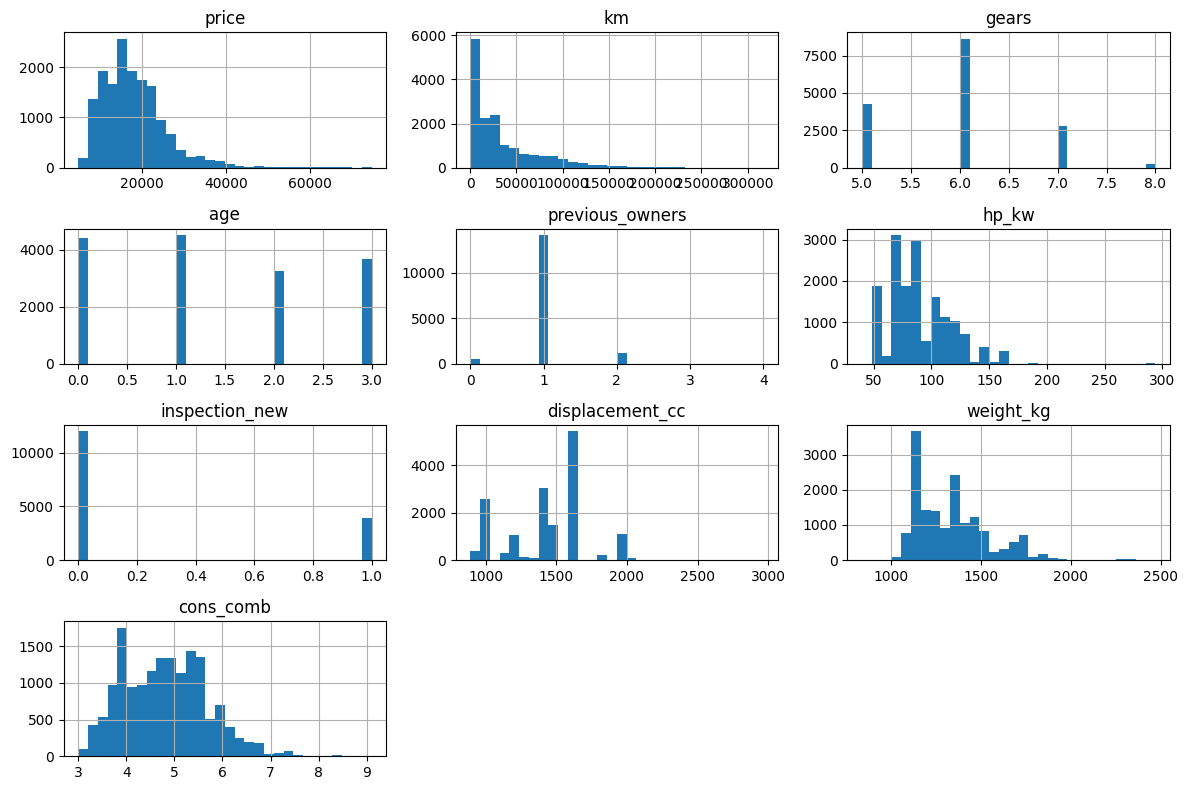

In [9]:
# Identify numerical features and plot histograms

num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

Some observations from the distribution plot:

- Price distribustion is skewed with most cars are priced less than 40000
- Most of the cars are having single owners
- Higher numbers of cars have 1500cc 
- Cars in the dataset are in the range of 0 to 3 years

#### **2.1.3** <font color =red> [3 marks] </font>
Identify categorical predictors and plot their frequency distributions.

Categorical columns:
['make_model', 'body_type', 'vat', 'type', 'fuel', 'comfort_convenience', 'entertainment_media', 'extras', 'safety_security', 'paint_type', 'upholstery_type', 'gearing_type', 'drive_chain']

Top categories for make_model:


make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2525
Opel Corsa        2216
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: count, dtype: int64

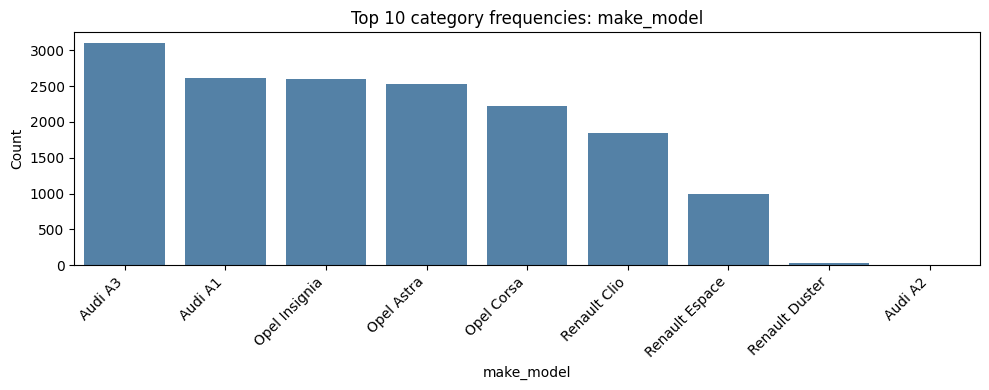


Top categories for body_type:


body_type
Sedans           8004
Station wagon    3677
Compact          3240
Van               817
Transporter        88
Off-Road           56
Coupe              25
Convertible         8
Name: count, dtype: int64

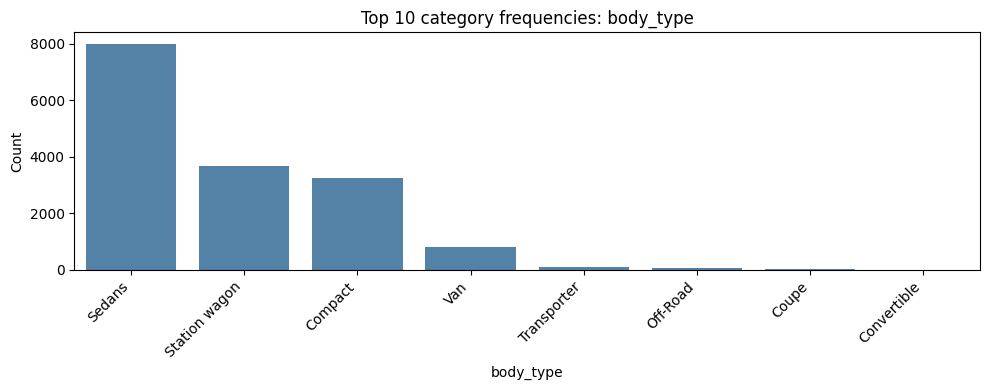


Top categories for vat:


vat
VAT deductible      15044
Price negotiable      871
Name: count, dtype: int64

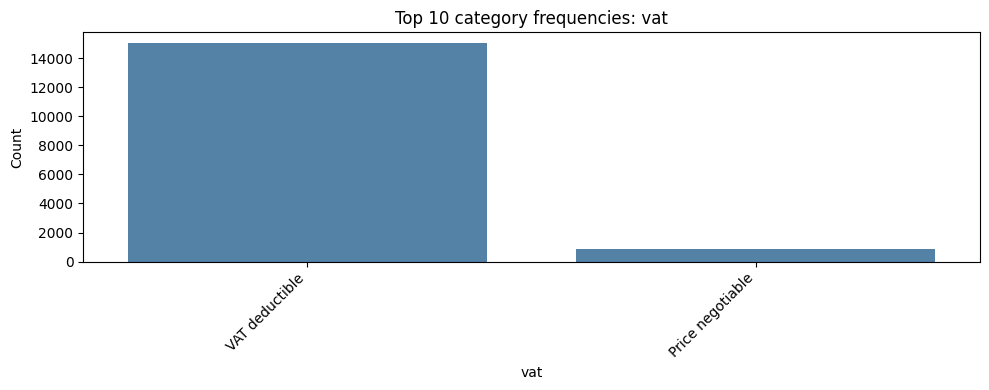


Top categories for type:


type
Used              11095
New                1649
Pre-registered     1364
Employee's car     1011
Demonstration       796
Name: count, dtype: int64

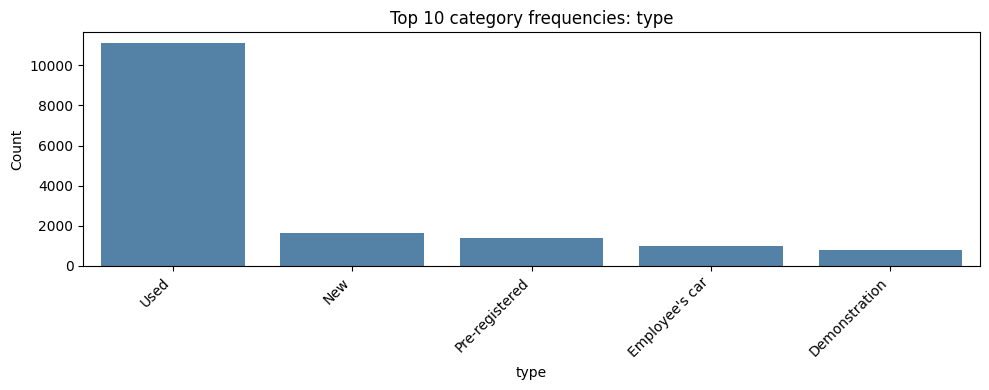


Top categories for fuel:


fuel
Benzine     8548
Diesel      7298
LPG/CNG       64
Electric       5
Name: count, dtype: int64

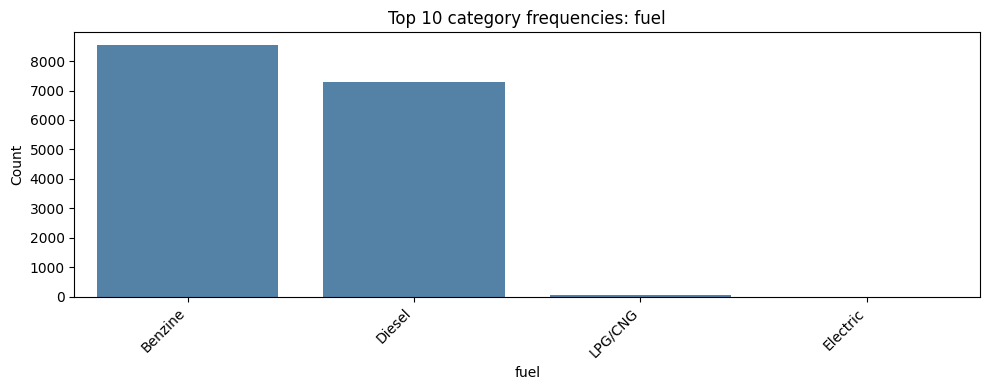


Top categories for comfort_convenience:


comfort_convenience
Air conditioning,Electrical side mirrors,Hill Holder,Power windows                                                                                                                                                                                                                                                                                                                                                                                                                             388
Air conditioning,Armrest,Automatic climate control,Cruise control,Electrical side mirrors,Leather steering wheel,Light sensor,Lumbar support,Multi-function steering wheel,Navigation system,Park Distance Control,Parking assist system sensors front,Parking assist system sensors rear,Power windows,Rain sensor,Seat heating,Start-stop system                                                                                                                                             187
Air conditioni

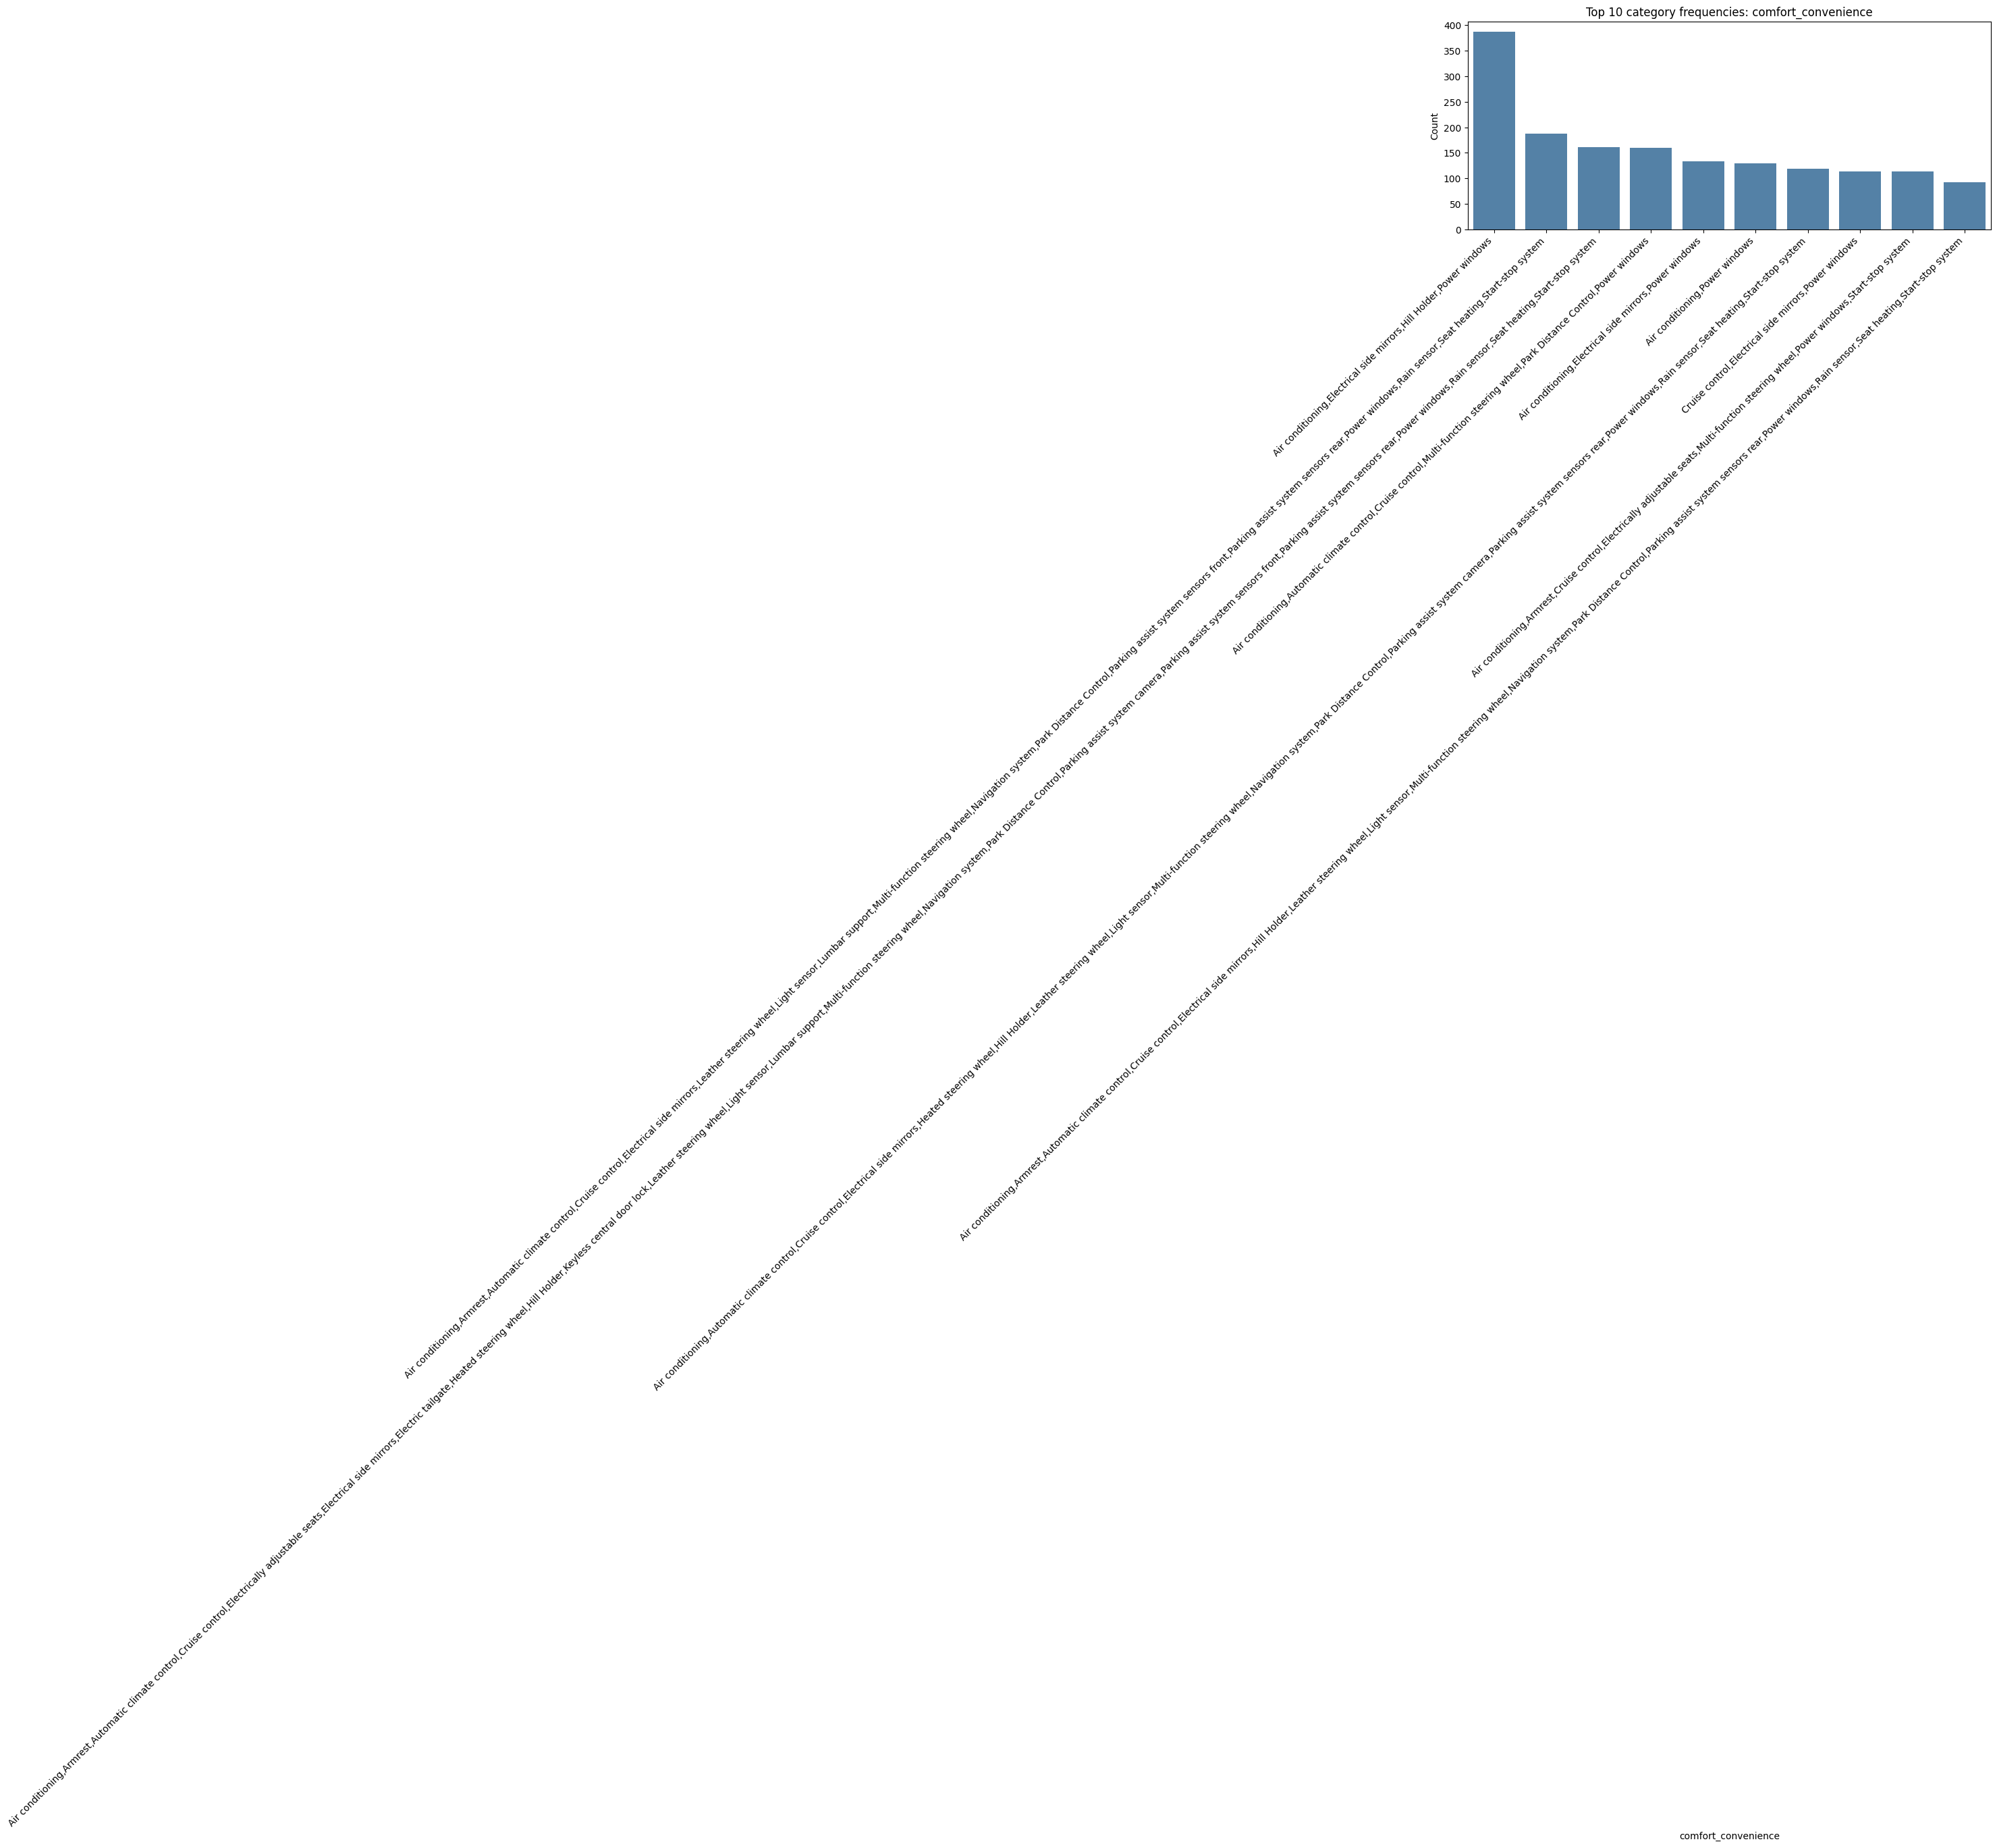


Top categories for entertainment_media:


entertainment_media
Bluetooth,Hands-free equipment,On-board computer,Radio,USB                  1737
Bluetooth,Hands-free equipment,MP3,On-board computer,Radio,USB              1134
Bluetooth,CD player,Hands-free equipment,MP3,On-board computer,Radio,USB    1009
On-board computer                                                            615
Radio                                                                        558
Bluetooth,Hands-free equipment,On-board computer,Radio                       515
On-board computer,Radio                                                      487
Bluetooth,CD player,Hands-free equipment,On-board computer,Radio,USB         466
Bluetooth,On-board computer,Radio                                            426
Bluetooth,CD player,Hands-free equipment,MP3,On-board computer,Radio         404
Name: count, dtype: int64

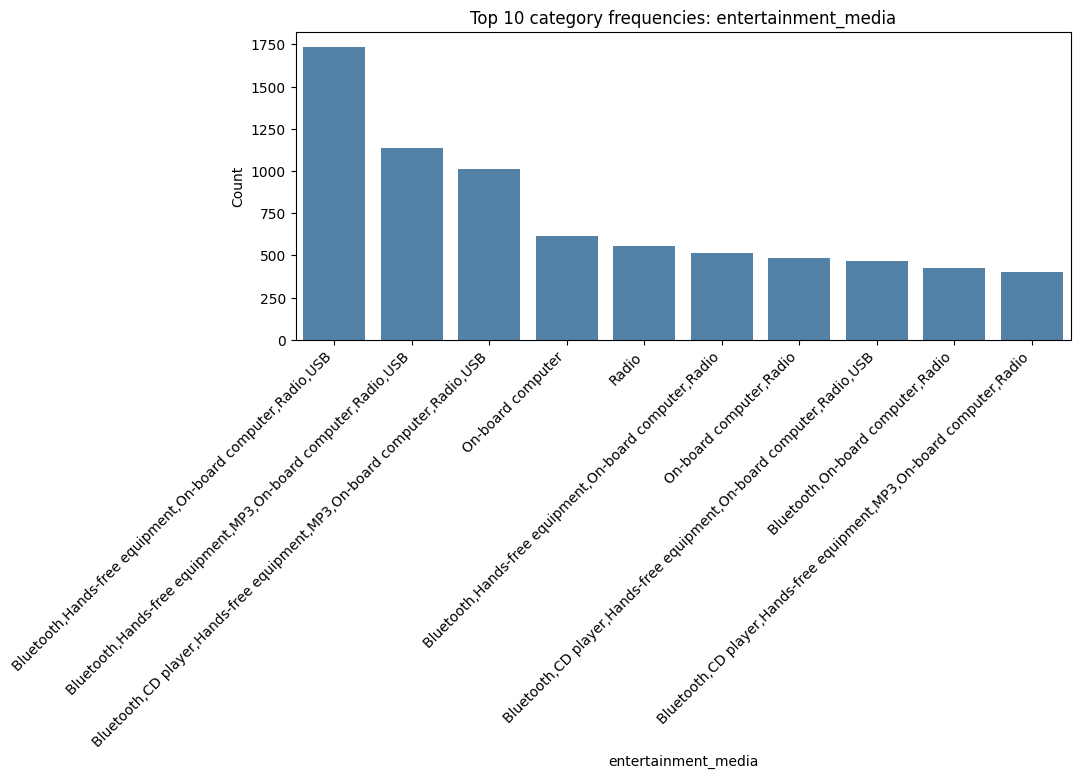


Top categories for extras:


extras
Alloy wheels                                     5785
Alloy wheels,Touch screen                         697
Roof rack                                         595
Alloy wheels,Voice Control                        582
Alloy wheels,Touch screen,Voice Control           544
Alloy wheels,Roof rack                            529
Alloy wheels,Sport seats                          382
Alloy wheels,Catalytic Converter                  275
Alloy wheels,Sport seats,Sport suspension         234
Alloy wheels,Catalytic Converter,Touch screen     228
Name: count, dtype: int64

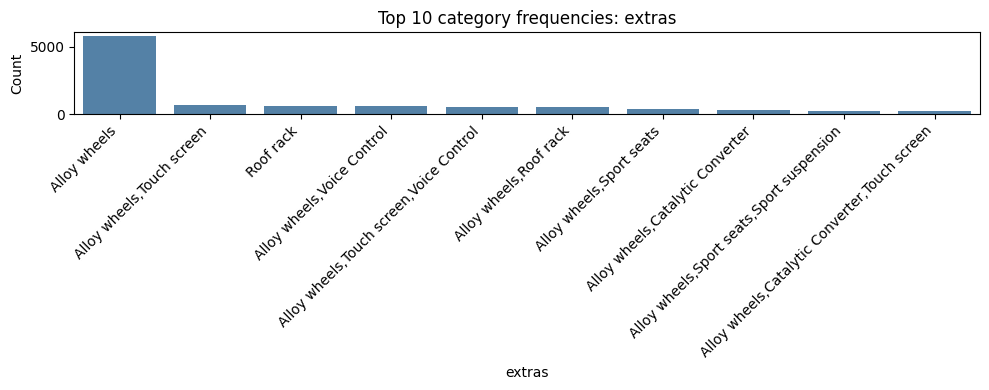


Top categories for safety_security:


safety_security
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Fog lights,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control                                                                                                                          729
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control                                                                                                                                     480
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Fog lights,Immobilizer,Isofix,LED Daytime Running Lights,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control                                             

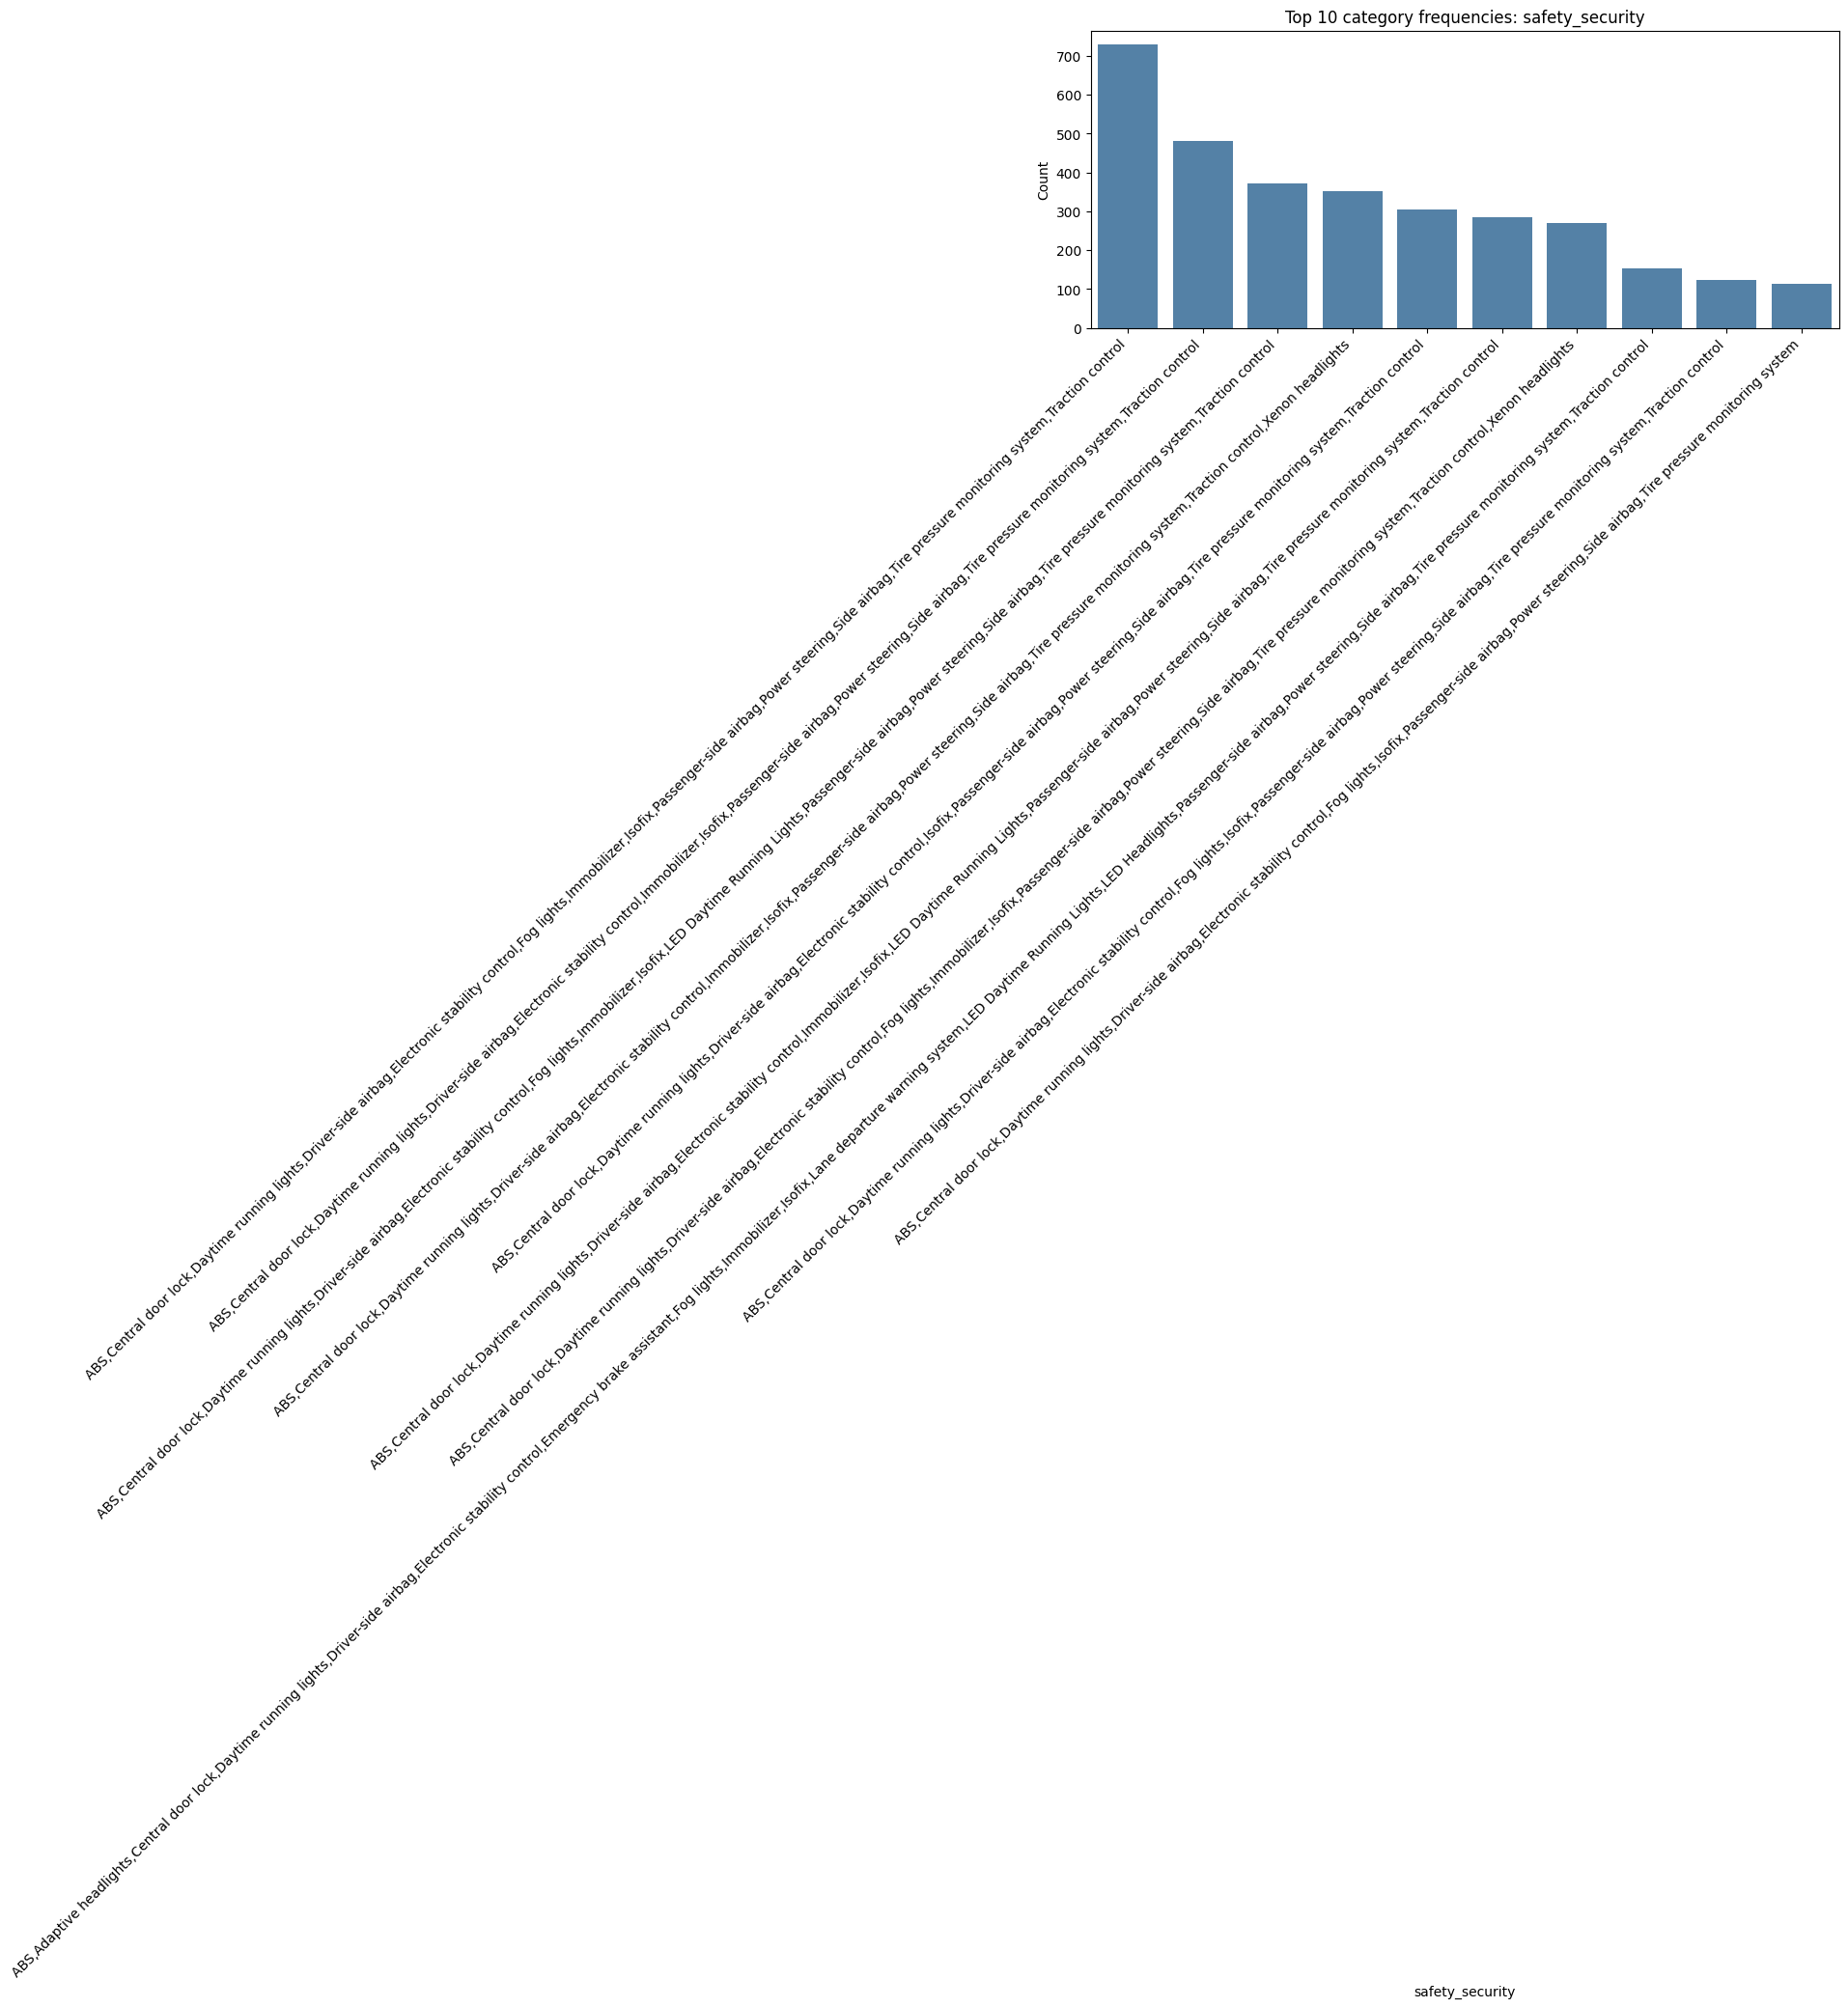


Top categories for paint_type:


paint_type
Metallic       15246
Uni/basic        637
Perl effect       32
Name: count, dtype: int64

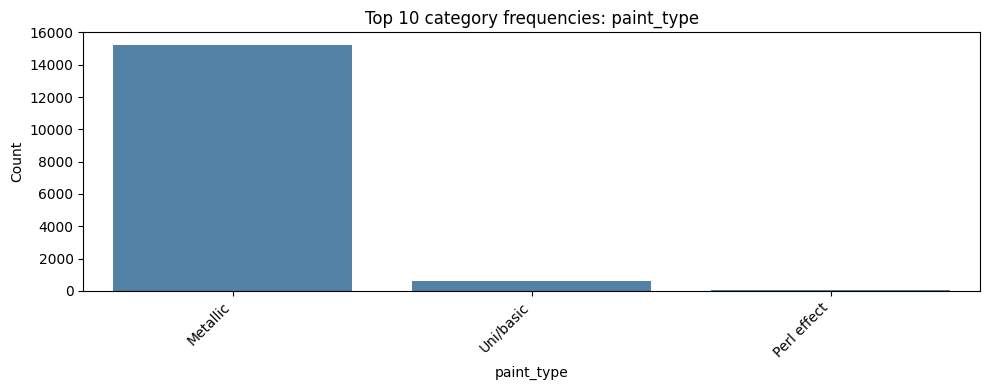


Top categories for upholstery_type:


upholstery_type
Cloth                12234
Part/Full Leather     3681
Name: count, dtype: int64

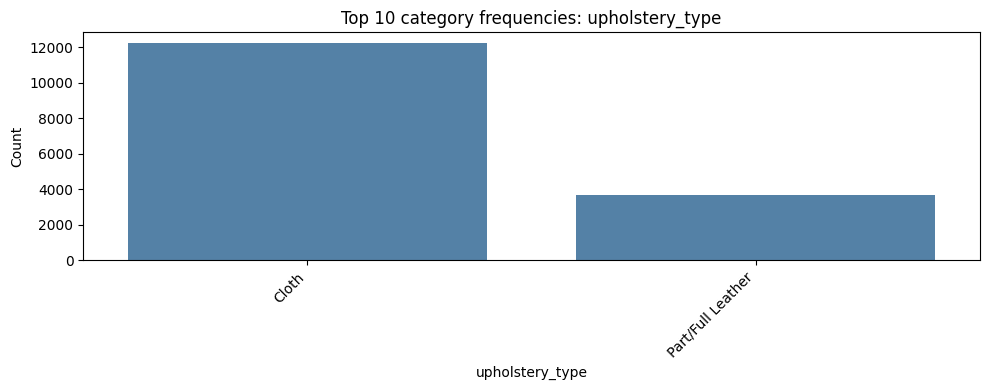


Top categories for gearing_type:


gearing_type
Manual            8149
Automatic         7297
Semi-automatic     469
Name: count, dtype: int64

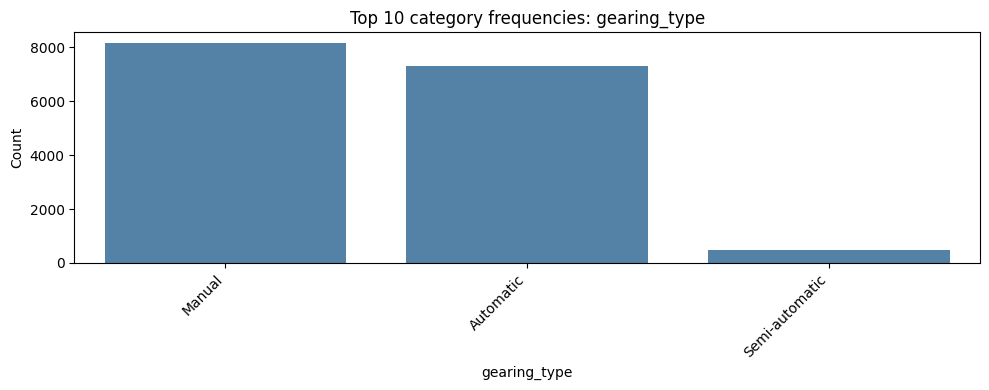


Top categories for drive_chain:


drive_chain
front    15707
4WD        204
rear         4
Name: count, dtype: int64

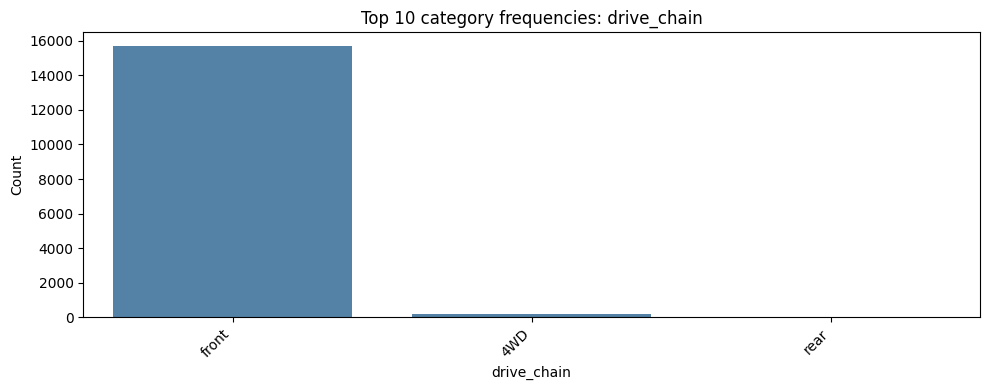

In [10]:
# Identify categorical columns and check their frequency distributions
cat_cols = df.select_dtypes(include=['object', 'string', 'category']).columns
print('Categorical columns:')
print(list(cat_cols))

for col in cat_cols:
    top_counts = df[col].value_counts(dropna=False).head(10)
    print(f"\nTop categories for {col}:")
    display(top_counts)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=top_counts.index.astype(str), y=top_counts.values, color='steelblue')
    plt.title(f"Top 10 category frequencies: {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Note**: Look carefully at the values stored in columns `["Comfort_Convenience", "Entertainment_Media", "Extras", "Safety_Security"]`.

Should they be considered categorical? Should they be dropped or handled any other way?

In [11]:
# Inspect multi-value feature-spec columns and decide handling strategy
spec_cols = ["comfort_convenience", "entertainment_media", "extras", "safety_security"]

spec_summary = []
for col in spec_cols:
    series = df[col].fillna("").astype(str)
    unique_combinations = series.nunique()
    avg_items = series.apply(lambda x: 0 if x.strip() == "" else len([t for t in x.split(",") if t.strip() != ""])).mean()
    max_items = series.apply(lambda x: 0 if x.strip() == "" else len([t for t in x.split(",") if t.strip() != ""])).max()

    print(f"\n--- {col} ---")
    print(f"Unique combinations: {unique_combinations}")
    print(f"Avg features listed per car: {avg_items:.2f}")
    print(f"Max features listed in a row: {max_items}")
    print("Top 5 raw combinations:")
    display(series.value_counts(dropna=False).head(5))

    token_counts = (
        series.str.split(",")
              .explode()
              .str.strip()
              .replace("", np.nan)
              .dropna()
              .value_counts()
    )

    print("Top 10 individual features:")
    display(token_counts.head(10))

    spec_summary.append({
        "column": col,
        "unique_combinations": int(unique_combinations),
        "avg_features_per_car": round(float(avg_items), 2),
        "max_features_in_row": int(max_items),
        "unique_individual_features": int(token_counts.shape[0])
    })

spec_summary_df = pd.DataFrame(spec_summary)
print("\nSummary of feature-spec columns:")
display(spec_summary_df)


--- comfort_convenience ---
Unique combinations: 6196
Avg features listed per car: 12.19
Max features listed in a row: 33
Top 5 raw combinations:


comfort_convenience
Air conditioning,Electrical side mirrors,Hill Holder,Power windows                                                                                                                                                                                                                                                                                                                                                                                                                             388
Air conditioning,Armrest,Automatic climate control,Cruise control,Electrical side mirrors,Leather steering wheel,Light sensor,Lumbar support,Multi-function steering wheel,Navigation system,Park Distance Control,Parking assist system sensors front,Parking assist system sensors rear,Power windows,Rain sensor,Seat heating,Start-stop system                                                                                                                                             187
Air conditioni

Top 10 individual features:


comfort_convenience
Air conditioning                      15095
Power windows                         14756
Electrical side mirrors               12488
Multi-function steering wheel         11744
Cruise control                        11622
Park Distance Control                 10655
Parking assist system sensors rear    10086
Leather steering wheel                 9735
Start-stop system                      9455
Automatic climate control              9197
Name: count, dtype: int64


--- entertainment_media ---
Unique combinations: 346
Avg features listed per car: 4.67
Max features listed in a row: 10
Top 5 raw combinations:


entertainment_media
Bluetooth,Hands-free equipment,On-board computer,Radio,USB                  1737
Bluetooth,Hands-free equipment,MP3,On-board computer,Radio,USB              1134
Bluetooth,CD player,Hands-free equipment,MP3,On-board computer,Radio,USB    1009
On-board computer                                                            615
Radio                                                                        558
Name: count, dtype: int64

Top 10 individual features:


entertainment_media
On-board computer       13222
Radio                   13196
Bluetooth               12685
Hands-free equipment    10371
USB                      9019
MP3                      6258
CD player                5024
Sound system             2244
Digital radio            2241
Television                 39
Name: count, dtype: int64


--- extras ---
Unique combinations: 659
Avg features listed per car: 2.24
Max features listed in a row: 10
Top 5 raw combinations:


extras
Alloy wheels                               5785
Alloy wheels,Touch screen                   697
Roof rack                                   595
Alloy wheels,Voice Control                  582
Alloy wheels,Touch screen,Voice Control     544
Name: count, dtype: int64

Top 10 individual features:


extras
Alloy wheels           13994
Voice Control           4338
Touch screen            4050
Sport seats             3104
Roof rack               3053
Catalytic Converter     2262
Sport suspension        1622
Sport package           1201
Trailer hitch            658
Shift paddles            508
Name: count, dtype: int64


--- safety_security ---
Unique combinations: 4442
Avg features listed per car: 12.79
Max features listed in a row: 29
Top 5 raw combinations:


safety_security
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Fog lights,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control                               729
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control                                          480
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Fog lights,Immobilizer,Isofix,LED Daytime Running Lights,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control    373
ABS,Central door lock,Daytime running lights,Driver-side airbag,Electronic stability control,Immobilizer,Isofix,Passenger-side airbag,Power steering,Side airbag,Tire pressure monitoring system,Traction control,Xenon hea

Top 10 individual features:


safety_security
ABS                                15022
Driver-side airbag                 14801
Power steering                     14489
Passenger-side airbag              14333
Electronic stability control       14077
Side airbag                        13998
Central door lock                  13575
Isofix                             12689
Traction control                   11845
Tire pressure monitoring system    11577
Name: count, dtype: int64


Summary of feature-spec columns:


,column,unique_combinations,avg_features_per_car,max_features_in_row,unique_individual_features
0,comfort_convenience,6196,12.19,33,38
1,entertainment_media,346,4.67,10,10
2,extras,659,2.24,10,17
3,safety_security,4442,12.79,29,29



### **Recommendation**

These are multi-label text fields, not standard single-category variables.
Do NOT treat them as one categorical label and do NOT drop them immediately.
Best approach: split into individual features and one-hot encode (multi-hot encoding)

#### **2.1.4** <font color =red> [3 marks] </font>
Fix columns with low frequency values and class imbalances.

Some information regarding values in the `Type` column that may help:
- *'Pre-registered'* cars are ones which have already been registered previously by the seller.
- *'New'* cars are not necessarily new cars, but new-like cars. These might also have multiple owners due to multiple pre-registrations as well.
- *'Employee's car'* are cars used by employees over a short period of time and small distance.
- *'Demonstration'* cars are used for trial purposes and also driven for a short time and distance.

Based on these, you can handle this particular column. For other columns, decide a strategy on your own.

In [14]:
print(df['type'].value_counts())
print("========\n")
print(df['body_type'].value_counts())
print("========\n")
print(df['fuel'].value_counts())
print("========\n")
print(df['paint_type'].value_counts())
print("========\n")
print(df['gearing_type'].value_counts())
print("========\n")
print(df['vat'].value_counts())

type
Used              11095
New                1649
Pre-registered     1364
Employee's car     1011
Demonstration       796
Name: count, dtype: int64

body_type
Sedans           8004
Station wagon    3677
Compact          3240
Van               817
Transporter        88
Off-Road           56
Coupe              25
Convertible         8
Name: count, dtype: int64

fuel
Benzine     8548
Diesel      7298
LPG/CNG       64
Electric       5
Name: count, dtype: int64

paint_type
Metallic       15246
Uni/basic        637
Perl effect       32
Name: count, dtype: int64

gearing_type
Manual            8149
Automatic         7297
Semi-automatic     469
Name: count, dtype: int64

vat
VAT deductible      15044
Price negotiable      871
Name: count, dtype: int64


### Fixing multiclass and low frequency in 'Type' column 

This is being done by grouping Pre-registered, Employee's car, Demonstration, New into a single category like Nearly New to reduce sparsity.

In [15]:
# Combine similar categories
df['type'] = df['type'].replace({
    'Pre-registered': 'Nearly New',
    "Employee's car": 'Nearly New',
    'Demonstration': 'Nearly New',
    'New': 'Nearly New'
})

# Check class distribution
print(df['type'].value_counts())

type
Used          11095
Nearly New     4820
Name: count, dtype: int64


Assigned the pre-registered, emplyee's car, demo car and new are all changed as 'nearly new' to reduce car imbalance.

###  Approach for fixing other low frequency values and class imbalance

Identified 3 other columns with similar class imbalance and low frequency issue as 'type'. Those are 'body_type', 'paint_type' and 'fuel' column.

Using a minimum value count for each of those columns 

In [16]:
# Fix columns as needed

def combine_rare_categories(series, min_count=50, new_label='Other'):
    value_counts = series.value_counts()
    rare = value_counts[value_counts < min_count].index
    return series.apply(lambda x: new_label if x in rare else x)

# Apply to each column
df['body_type'] = combine_rare_categories(df['body_type'], min_count=900)
df['fuel'] = combine_rare_categories(df['fuel'], min_count=70)
df['paint_type'] = combine_rare_categories(df['paint_type'], min_count=700)

# Check new distributions
print(df['body_type'].value_counts())
print(df['fuel'].value_counts())
print(df['paint_type'].value_counts())

body_type
Sedans           8004
Station wagon    3677
Compact          3240
Other             994
Name: count, dtype: int64
fuel
Benzine    8548
Diesel     7298
Other        69
Name: count, dtype: int64
paint_type
Metallic    15246
Other         669
Name: count, dtype: int64


#### **2.1.5** <font color =red> [3 marks] </font>
Identify target variable and plot the frequency distributions. Apply necessary transformations.

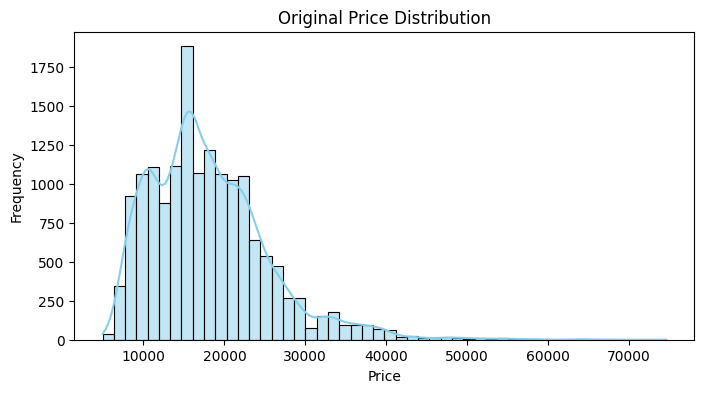

Skewness of price: 1.24


In [ ]:
# Plot histograms for target feature
target = 'price'

# Plot original distribution
plt.figure(figsize=(8, 4))
sns.histplot(df[target], bins=50, kde=True, color='skyblue')
plt.title('Original Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Check skewness
skewness = df[target].skew()
print(f"Skewness of {target}: {skewness:.2f}")



**The target variable seems to be skewed. Perform suitable transformation on the target.**

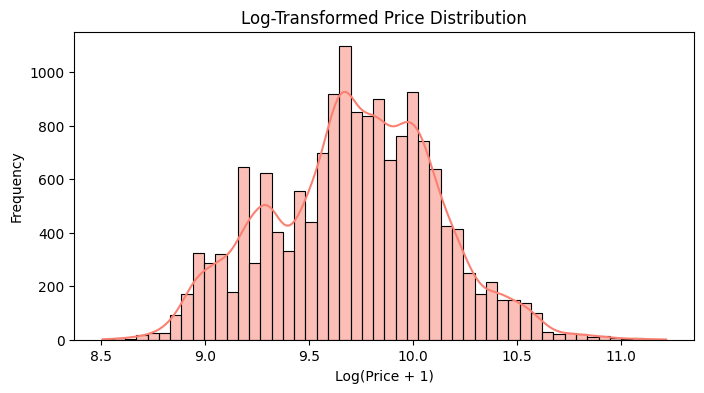

Applied log transformation to target variable.


In [ ]:
# Transform the target feature

# Apply log transformation as it is skewed
if skewness > 1:
    df[target + '_log'] = np.log1p(df[target])
    plt.figure(figsize=(8, 4))
    sns.histplot(df[target + '_log'], bins=50, kde=True, color='salmon')
    plt.title('Log-Transformed Price Distribution')
    plt.xlabel('Log(Price + 1)')
    plt.ylabel('Frequency')
    plt.show()
    print('Applied log transformation to target variable.')
else:
    print('No transformation needed for target variable.')


### **2.2 Correlation analysis** <font color = red> [6 marks] </font>

#### **2.2.1** <font color =red> [3 marks] </font>
Plot the correlation map between features and target variable.

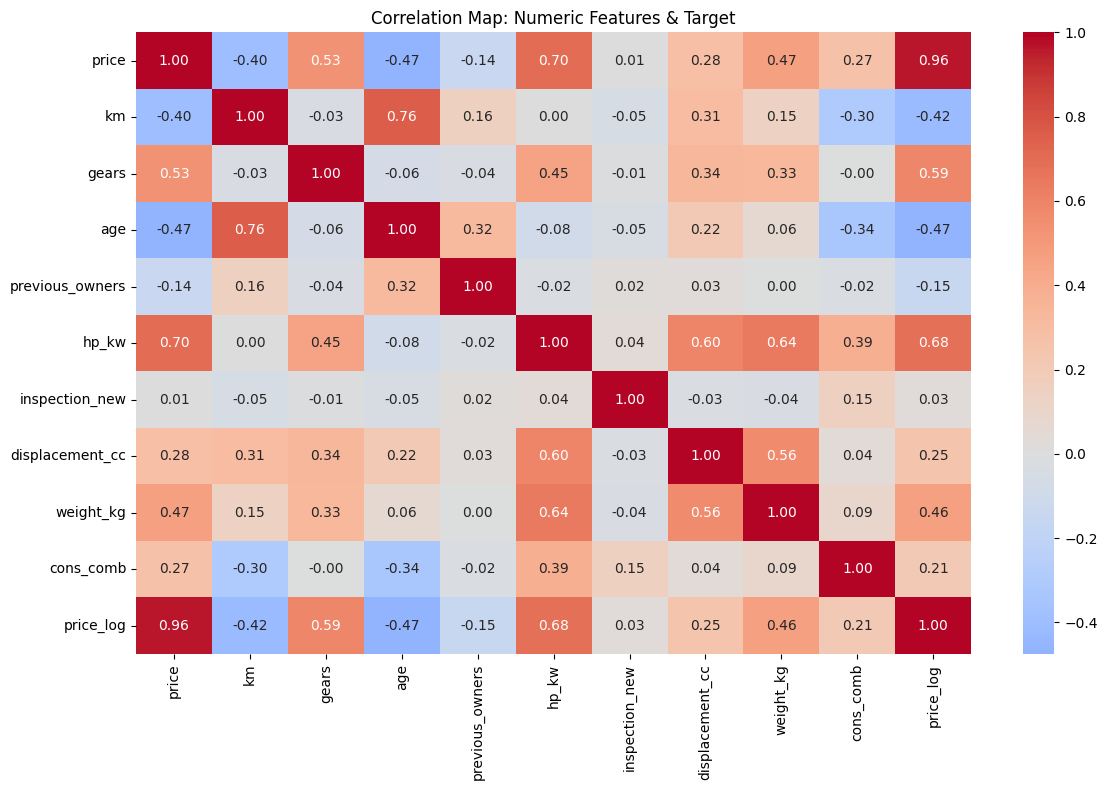

Correlation with target variable:


price_log          1.000000
price              0.962281
hp_kw              0.678024
gears              0.588194
weight_kg          0.464597
displacement_cc    0.254854
cons_comb          0.211097
inspection_new     0.030927
previous_owners   -0.152029
km                -0.419189
age               -0.474618
Name: price_log, dtype: float64

In [19]:
# Visualise correlation

# Use log-transformed target if available
target_col = 'price_log' if 'price_log' in df.columns else 'price'

# Select only numeric columns for correlation
num_cols = df.select_dtypes(include=["number"]).columns

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Map: Numeric Features & Target")
plt.tight_layout()
plt.show()

# Show correlation of each feature with target
feature_corr = corr_matrix[target_col].sort_values(ascending=False)
print("Correlation with target variable:")
display(feature_corr)

Price is highly correlated with hp_kw, gears, weight_kg with moderate correlation seen with displacement_cc, cons_comb and low correlation with inspection_new. There is negative correlation wiht previous_owners, km runs, and age of the vehicle.

#### **2.2.2** <font color =red> [3 marks] </font>
Analyse correlation between categorical features and target variable.

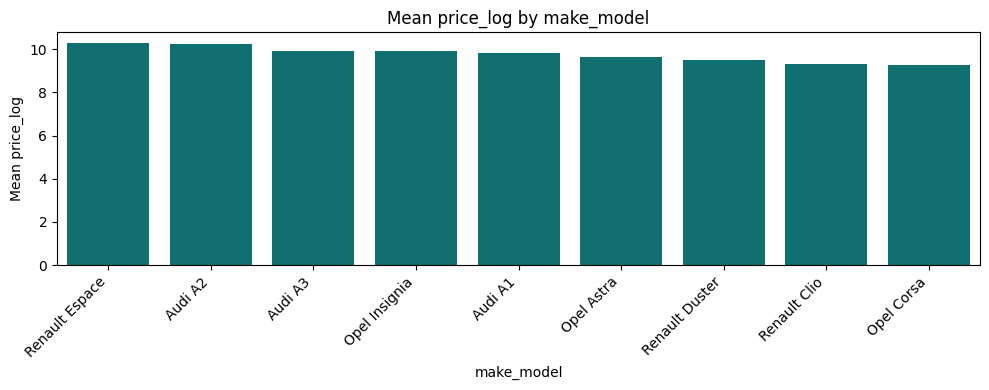

Mean price_log for each category in make_model:


make_model
Renault Espace    10.271724
Audi A2           10.247113
Audi A3            9.928165
Opel Insignia      9.912658
Audi A1            9.817643
Opel Astra         9.626041
Renault Duster     9.483063
Renault Clio       9.335822
Opel Corsa         9.276059
Name: price_log, dtype: float64

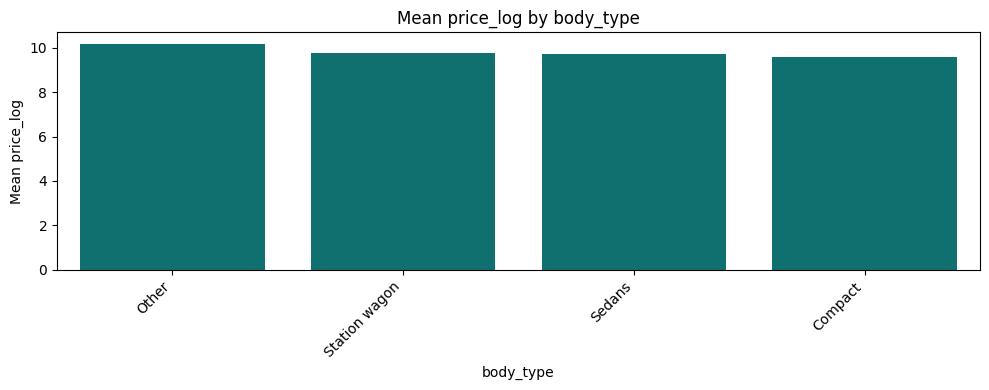

Mean price_log for each category in body_type:


body_type
Other            10.174948
Station wagon     9.753456
Sedans            9.716144
Compact           9.555735
Name: price_log, dtype: float64

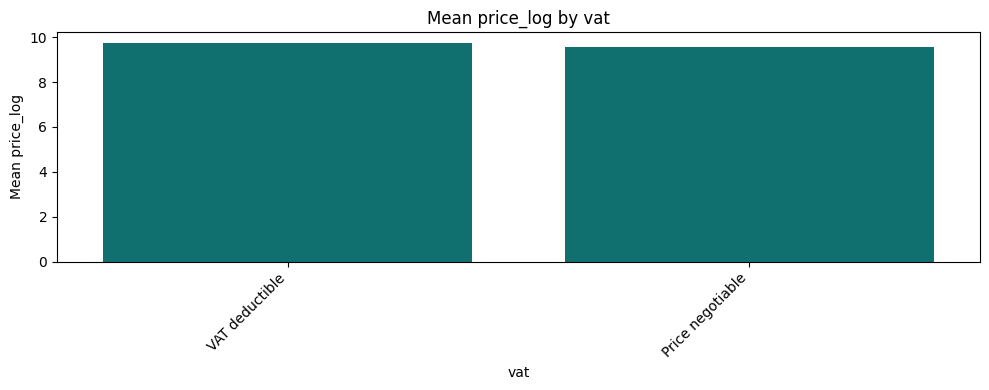

Mean price_log for each category in vat:


vat
VAT deductible      9.730286
Price negotiable    9.556299
Name: price_log, dtype: float64

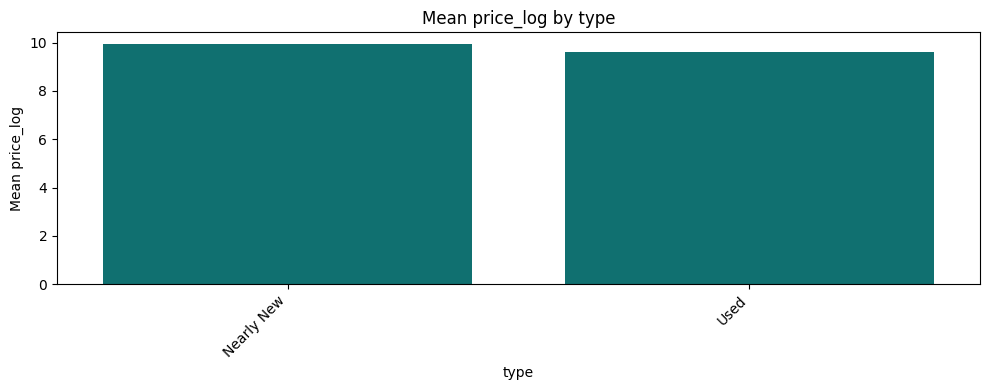

Mean price_log for each category in type:


type
Nearly New    9.928387
Used          9.630566
Name: price_log, dtype: float64

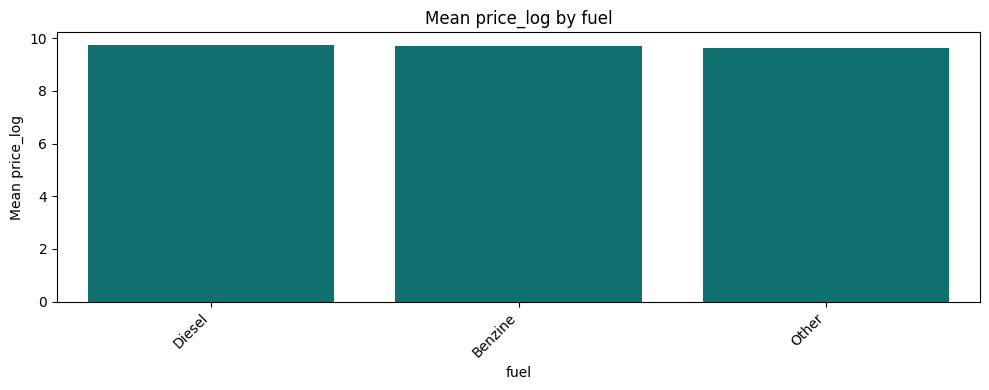

Mean price_log for each category in fuel:


fuel
Diesel     9.734926
Benzine    9.709328
Other      9.639463
Name: price_log, dtype: float64

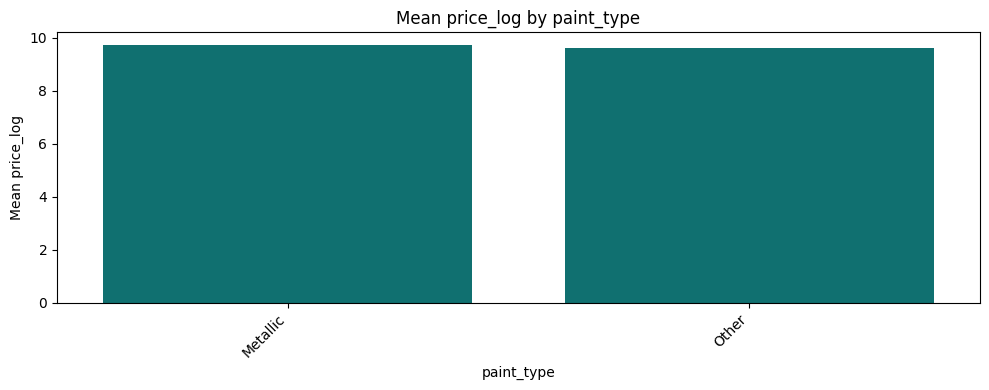

Mean price_log for each category in paint_type:


paint_type
Metallic    9.725404
Other       9.615009
Name: price_log, dtype: float64

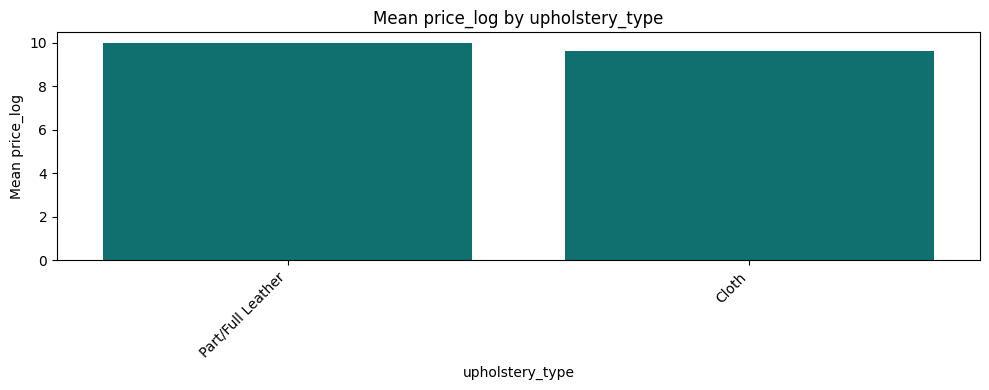

Mean price_log for each category in upholstery_type:


upholstery_type
Part/Full Leather    9.981383
Cloth                9.642348
Name: price_log, dtype: float64

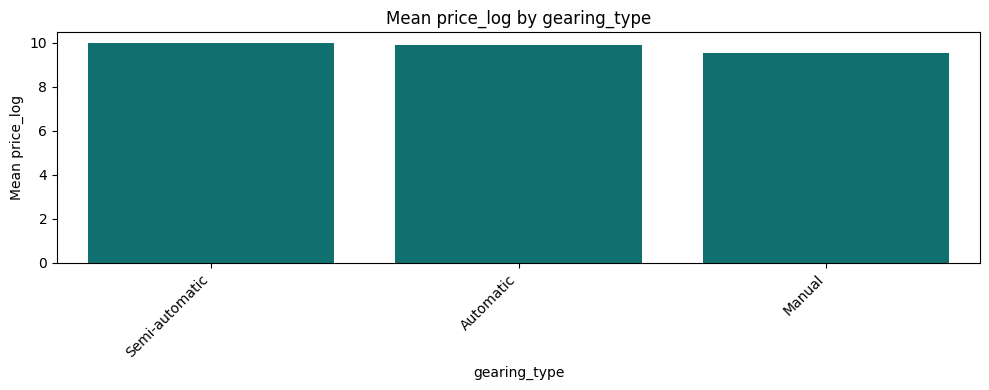

Mean price_log for each category in gearing_type:


gearing_type
Semi-automatic    9.972004
Automatic         9.906177
Manual            9.540276
Name: price_log, dtype: float64

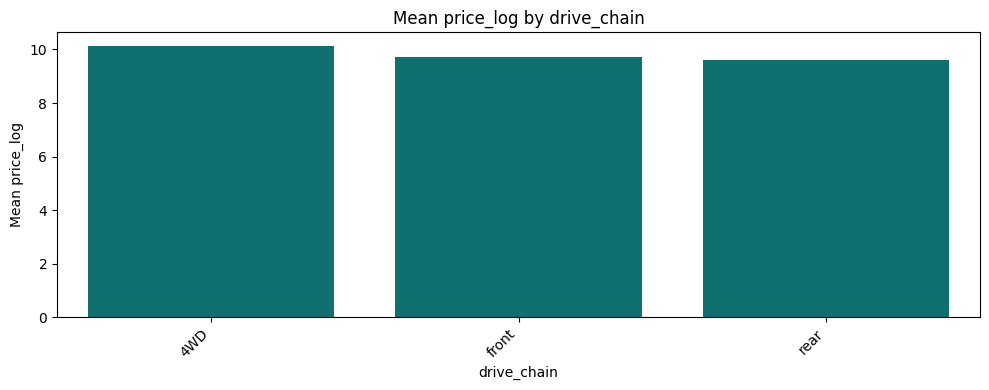

Mean price_log for each category in drive_chain:


drive_chain
4WD      10.133491
front     9.715432
rear      9.606166
Name: price_log, dtype: float64

In [20]:
# Comparing average values of target for different categories

# Use log-transformed target if available
target_col = 'price_log' if 'price_log' in df.columns else 'price'

# Identify categorical columns (excluding multi-label columns)
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
multi_label_cols = ['comfort_convenience', 'entertainment_media', 'extras', 'safety_security']
cat_cols = [col for col in cat_cols if col not in multi_label_cols]

# Plot mean target value for each category in top categorical columns
for col in cat_cols:
    if df[col].nunique() < 20:  # Only plot for columns with fewer categories
        plt.figure(figsize=(10, 4))
        mean_target = df.groupby(col)[target_col].mean().sort_values(ascending=False)
        sns.barplot(x=mean_target.index.astype(str), y=mean_target.values, color='teal')
        plt.title(f'Mean {target_col} by {col}')
        plt.xlabel(col)
        plt.ylabel(f'Mean {target_col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print(f"Mean {target_col} for each category in {col}:")
        display(mean_target)

### **2.3 Outlier analysis** <font color = red> [5 marks] </font>

#### **2.3.1** <font color =red> [2 marks] </font>
Identify potential outliers in the data.

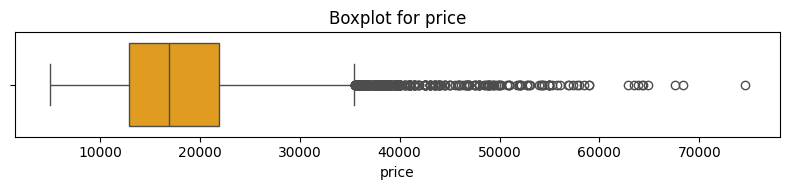

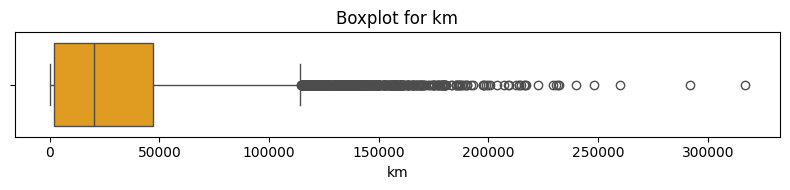

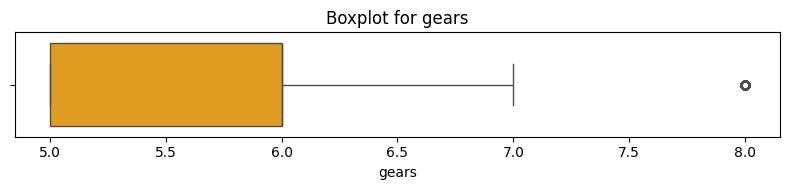

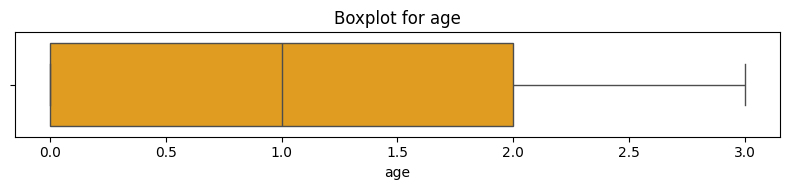

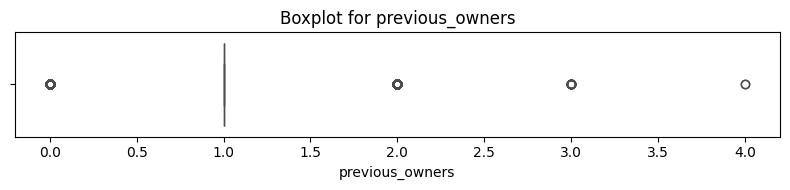

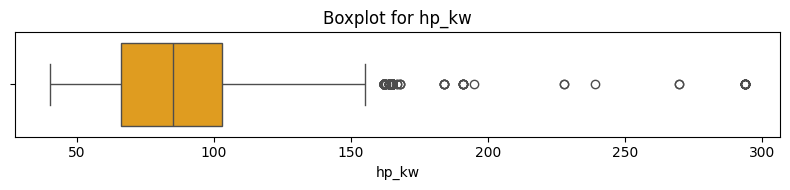

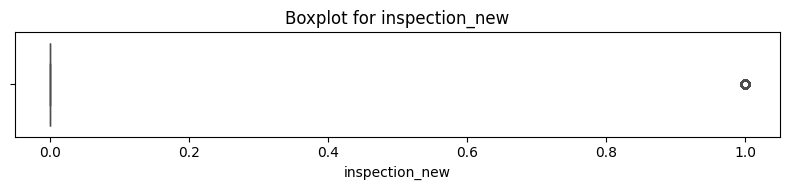

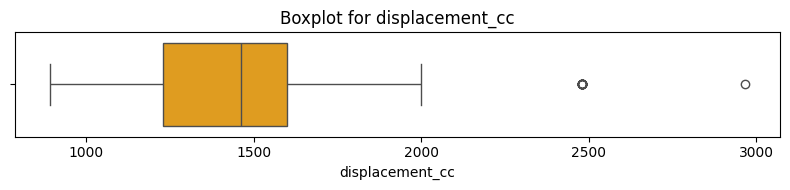

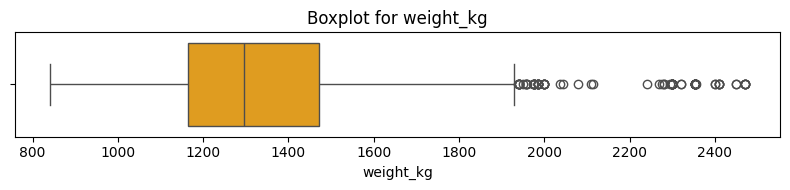

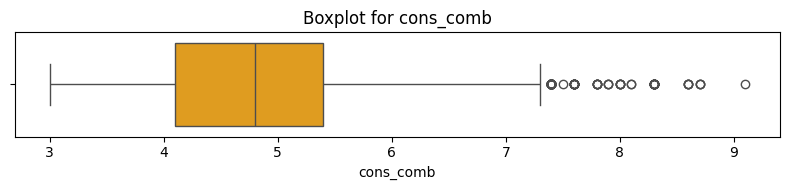

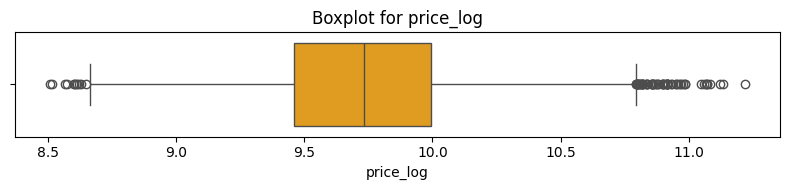

Outlier counts for each numeric column:
price: 479 outliers
km: 689 outliers
gears: 225 outliers
age: 0 outliers
previous_owners: 1757 outliers
hp_kw: 361 outliers
inspection_new: 3932 outliers
displacement_cc: 21 outliers
weight_kg: 87 outliers
cons_comb: 125 outliers
price_log: 71 outliers


In [21]:
# Outliers present in each column

# Use numeric columns for outlier detection
num_cols = df.select_dtypes(include=["number"]).columns

# Visualize boxplots for each numeric column
for col in num_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot for {col}')
    plt.tight_layout()
    plt.show()

# Identify outliers using IQR method
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = outliers.shape[0]
    outlier_summary[col] = outlier_count

print("Outlier counts for each numeric column:")
for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")

#### **2.3.2** <font color =red> [3 marks] </font>
Handle the outliers suitably.

In [22]:
# Handle outliers

# Remove outliers using IQR method for each numeric column
num_cols = df.select_dtypes(include=["number"]).columns

df_outlier_cleaned = df.copy()
for col in num_cols:
    Q1 = df_outlier_cleaned[col].quantile(0.25)
    Q3 = df_outlier_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_outlier_cleaned = df_outlier_cleaned[(df_outlier_cleaned[col] >= lower_bound) & (df_outlier_cleaned[col] <= upper_bound)]

print(f"Data shape after outlier removal: {df_outlier_cleaned.shape}")
df = df_outlier_cleaned.reset_index(drop=True)

Data shape after outlier removal: (9317, 24)


### **2.4 Feature Engineering** <font color = red> [11 marks] </font>

#### **2.4.1**
Fix any redundant columns and create new ones if needed.

In [23]:
# Fix/create columns as needed

# Drop columns with high redundancy or low variance
redundant_cols = []
for col in df.columns:
    if df[col].nunique() <= 1:
        redundant_cols.append(col)
        print(f"Column '{col}' is redundant (only one unique value).")

# Drop identified redundant columns
if redundant_cols:
    df.drop(columns=redundant_cols, inplace=True)
    print(f"Dropped redundant columns: {redundant_cols}")

# Example: Create new feature - car age category
if 'age' in df.columns:
    df['age_category'] = pd.cut(df['age'], bins=[0, 3, 7, 15, 100], labels=['New', 'Mid', 'Old', 'Very Old'])
    print("Created 'age_category' column.")

# Example: Create new feature - power-to-weight ratio
if 'hp_kw' in df.columns and 'weight_kg' in df.columns:
    df['power_weight_ratio'] = df['hp_kw'] / df['weight_kg']
    print("Created 'power_weight_ratio' column.")

Column 'previous_owners' is redundant (only one unique value).
Column 'inspection_new' is redundant (only one unique value).
Dropped redundant columns: ['previous_owners', 'inspection_new']
Created 'age_category' column.
Created 'power_weight_ratio' column.


#### **2.4.2** <font color =red> [4 marks] </font>
Analysis and feature engineering on `['Comfort_Convenience', 'Entertainment_Media', 'Extras', 'Safety_Security']`.

These columns contains lists of features present. Decide on how to include these features in the predictors.

In [24]:
# Check unique values in each feature spec column
spec_cols = ['comfort_convenience', 'entertainment_media', 'extras', 'safety_security']

common_features_dict = {}
rare_features_dict = {}

for col in spec_cols:
    tokens = (
        df[col].fillna('')
        .str.split(',')
        .explode()
        .str.strip()
        .replace('', np.nan)
        .dropna()
    )
    feature_counts = tokens.value_counts()
    total_cars = df.shape[0]
    feature_freq = feature_counts / total_cars
    # Features present in >95% of cars
    common_features = feature_freq[feature_freq > 0.80].index.tolist()
    # Features present in <5% of cars
    rare_features = feature_freq[feature_freq < 0.05].index.tolist()
    common_features_dict[col] = common_features
    rare_features_dict[col] = rare_features
    print(f"\nFeatures in '{col}' present in >80% of cars: " + str(len(common_features)))
    print(common_features)
    print(f"\nFeatures in '{col}' present in <5% of cars: " + str(len(rare_features)))
    print(rare_features)



Features in 'comfort_convenience' present in >80% of cars: 2
['Air conditioning', 'Power windows']

Features in 'comfort_convenience' present in <5% of cars: 11
['Electrically heated windshield', 'Parking assist system self-steering', 'Panorama roof', 'Heads-up display', 'Auxiliary heating', 'Sunroof', 'Massage seats', 'Air suspension', 'Wind deflector', 'Leather seats', 'Windshield']

Features in 'entertainment_media' present in >80% of cars: 1
['On-board computer']

Features in 'entertainment_media' present in <5% of cars: 1
['Television']

Features in 'extras' present in >80% of cars: 1
['Alloy wheels']

Features in 'extras' present in <5% of cars: 9
['Trailer hitch', 'Shift paddles', 'Ski bag', 'Winter tyres', 'Cab or rented Car', 'Handicapped enabled', 'Tuned car', 'Right hand drive', 'Sliding door']

Features in 'safety_security' present in >80% of cars: 7
['ABS', 'Driver-side airbag', 'Power steering', 'Passenger-side airbag', 'Side airbag', 'Electronic stability control', 'Cen

## Recommendation

We are taking 80% of the features and would be dropping the ones which are present in less than 5% of cars.

Out of these features, we will check the ones which are present in most of the cars or are absent from most of the cars. These kinds of features can be removed as they just increase the dimensionality without explaining the variance.

In [25]:
# Drop features from df
for col in spec_cols:
    rare_feats = rare_features_dict[col]
    def filter_rare_features(row):
        features = [f.strip() for f in str(row).split(',') if f.strip()]
        filtered = [f for f in features if f not in rare_feats]
        return ', '.join(filtered)
    df[col] = df[col].apply(filter_rare_features)

#### **2.4.3** <font color =red> [3 marks] </font>
Perform feature encoding.

In [26]:
# Encode features
mlb_dict = {}
for col in spec_cols:
    # Split features for each car
    feature_lists = df[col].fillna('').apply(lambda x: [f.strip() for f in x.split(',') if f.strip()])
    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(feature_lists)
    # Create DataFrame with encoded features
    encoded_df = pd.DataFrame(encoded, columns=[f"{col}_" + feat for feat in mlb.classes_], index=df.index)
    df = pd.concat([df, encoded_df], axis=1)
    mlb_dict[col] = mlb

df.drop(columns=spec_cols, inplace=True)

# One-hot encode remaining categorical columns using pandas get_dummies
multi_label_cols = ['comfort_convenience', 'entertainment_media', 'extras', 'safety_security']
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in multi_label_cols and col not in spec_cols and col != target_col]

if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print(f"Applied get_dummies to columns: {cat_cols}")
else:
    print("No categorical columns left for get_dummies.")
    
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

Applied get_dummies to columns: ['make_model', 'body_type', 'vat', 'type', 'fuel', 'paint_type', 'upholstery_type', 'gearing_type', 'drive_chain', 'age_category']


#### **2.4.4** <font color =red> [2 marks] </font>
Split the data into training and testing sets.

In [27]:
# Split data
target_col = 'price_log' if 'price_log' in df.columns else 'price'
X = df.drop(columns=[target_col])
y = df[target_col]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (7453, 102), Test shape: (1864, 102)


#### **2.4.5** <font color =red> [2 marks] </font>
Scale the features.

In [ ]:
# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Scaled train shape: {X_train_scaled.shape}, Scaled test shape: {X_test_scaled.shape}")

Scaled train shape: (7453, 102), Scaled test shape: (1864, 102)


Using MinMaxScaler() scaled the data.

## **3 Linear Regression Models** <font color =red> [35 marks] </font>


### **3.1 Baseline Linear Regression Model** <font color =red> [10 marks] </font>

#### **3.1.1** <font color =red> [5 marks] </font>
Build and fit a basic linear regression model. Perform evaluation using suitable metrics.

In [29]:
# Initialise and train model
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
y_train_pred = lr.predict(X_train) # Predicting on the training set
y_test_pred = lr.predict(X_test) # Predicting values on the test set

In [31]:
pd.DataFrame({'Actual Train': y_train, 'Predicted Train': np.round(y_train_pred, 2)}).sample(5, random_state = 0)

,Actual Train,Predicted Train
1359,9.923339,9.88
3498,10.125871,10.13
998,9.735128,9.68
4609,10.165506,10.18
4600,10.199919,10.19


In [32]:
pd.DataFrame({'Actual Test': y_test, 'Predicted Test': np.round(y_test_pred, 2)}).sample(5, random_state = 0)  # Testing data

,Actual Test,Predicted Test
8358,9.200391,9.17
6209,9.332646,9.24
4793,9.711176,9.67
2191,9.994288,10.04
1044,9.729194,9.73


In [33]:
# Evaluate the model's performance
def regression_metrics(y_train, y_train_pred, y_test, y_test_pred):    
    def compute_metrics(y, y_pred):
        # Compute evaluation metrics
        mse = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y, y_pred)
        mape = mean_absolute_percentage_error(y, y_pred) * 100
        r2 = r2_score(y, y_pred)

        # Compute statistics for comparison
        var = y.var()  # Compares to the MSE
        std = y.std()  # Compares to the RMSE
        mean_val = y.mean()  # Acts as the 'typical value' when comparing to the MAE
        
        return mse, var, rmse, std, mae, mean_val, mape, r2

    metrics_train = compute_metrics(y_train, y_train_pred)
    metrics_test = compute_metrics(y_test, y_test_pred)
    
    return pd.DataFrame({'Dataset': ['Training', 'Testing'], 'MSE': [metrics_train[0], metrics_test[0]], 'Var': [metrics_train[1], metrics_test[1]],
                         'RMSE': [metrics_train[2], metrics_test[2]], 'Std Dev': [metrics_train[3], metrics_test[3]],
                         'MAE': [metrics_train[4], metrics_test[4]], 'Mean': [metrics_train[5], metrics_test[5]],'MAPE': [metrics_train[6], metrics_test[6]], 
                         'R²': [metrics_train[7], metrics_test[7]]}).set_index('Dataset')



In [34]:
df_metrics = regression_metrics(y_train, y_train_pred, y_test, y_test_pred).round(3)
df_metrics

,MSE,Var,RMSE,Std Dev,MAE,Mean,MAPE,R²
Dataset,,,,,,,,
Training,0.003,0.141,0.051,0.376,0.038,9.690,0.394,0.982
Testing,0.003,0.142,0.050,0.377,0.038,9.688,0.396,0.982


From the above we can observe the following:

- The model achieves excellent performance, with low error metrics (MSE, RMSE, MAE, MAPE).
- R2 of 0.98 suggests the model captures almost all relevant patterns in the data.
- Similar scores for training and testing indicate minimal overfitting.
- Features and preprocessing steps are effective for price prediction.

#### **3.1.2** <font color =red> [5 marks] </font>
Analyse residuals and check other assumptions of linear regression.

Check for linearity by analysing residuals vs predicted values

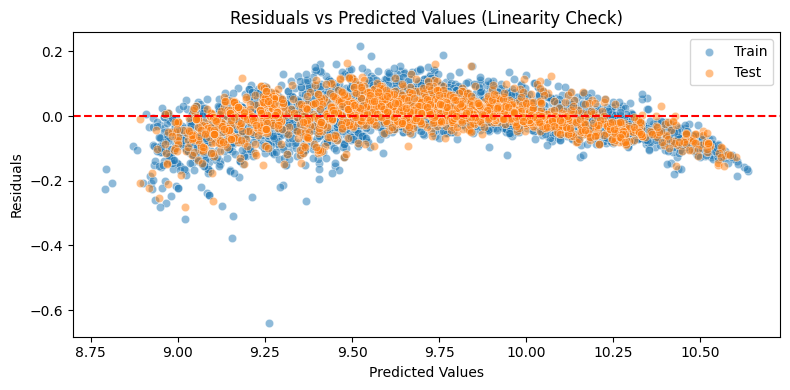

In [35]:
# Linearity check: Plot residuals vs fitted values
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

plt.figure(figsize=(8, 4))
sns.scatterplot(x = y_train_pred, y = residuals_train, label = 'Train', alpha=0.5)
sns.scatterplot(x = y_test_pred, y = residuals_test, label = 'Test', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values (Linearity Check)')
plt.tight_layout()
plt.show()



### Few observation from the plot:

- The model is systematically underpredicting in the middle and overpredicting at the extremes. 
- The model shows non-linearity—your and the model is missing some curvature in the relationship between features and the target.
- Both Train (blue) and Test (orange) follow the same pattern and it suggests the issue has model bias, not overfitting
- The vertical spread of residuals is:
    - Wider around the middle (≈ 9.3–9.8)
    - Narrower toward the extremes (low and high predictions)Shows mild heteroscedasticity

Check normality in residual distribution

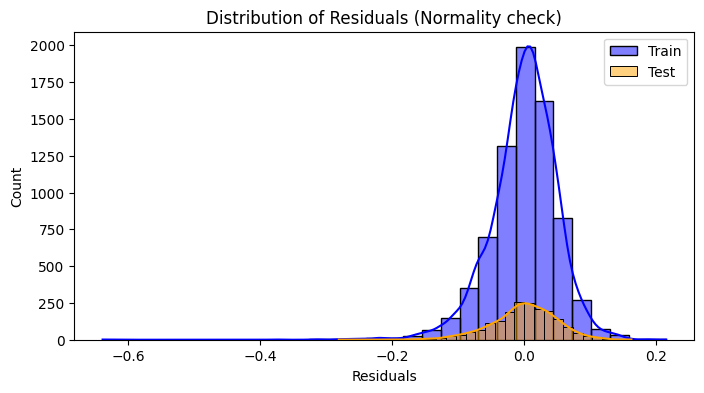

In [36]:
# Check the normality of residuals by plotting their distribution
plt.figure(figsize=(8, 4))
sns.histplot(residuals_train, kde = True, bins = 30, color = 'blue', label = 'Train', alpha = 0.5)
sns.histplot(residuals_test, kde = True, bins = 30, color = 'orange', label = 'Test', alpha = 0.5)
plt.xlabel('Residuals'); 
plt.title('Distribution of Residuals (Normality check)')
plt.legend()




### Few observations from above: 
- Residuals are roughly centered around 0 
- Shape is approximately bell-shaped, but:
- Slight skewness (left tail is longer)
- A few outliers (notably around -0.6)
- Slight peakedness / non-perfect normality

### Combined analysis:
- Because the model overpredicts at extremes and underpredicts in the middle in the Test vs Train scattter plot
- We are getting systematic negative residuals in some regions
- This creates the longer left tail in the histogram

Check multicollinearity using Variance Inflation Factor (VIF) and handle features with high VIF.

In [37]:
# Check for multicollinearity and handle
def calculate_vif(dataframe):
    vif_data = []
    for i in range(dataframe.shape[1]):
        vif_value = variance_inflation_factor(dataframe.values, i)
        vif_data.append({'Predictor': dataframe.columns[i], 'VIF': vif_value})
    return pd.DataFrame(vif_data)


In [38]:
# Check for NaN or infinite values
print(np.any(np.isnan(X_train)))
print(np.any(np.isinf(X_train)))

False
False


In [39]:
vif_df = calculate_vif(X_train)
vif_df = vif_df.sort_values('VIF', ascending = False)
vif_df.round(3).set_index('Predictor')

,VIF
Predictor,
hp_kw,1299.621
power_weight_ratio,1096.947
weight_kg,734.271
gears,275.965
drive_chain_front,230.026
...,...
fuel_Other,1.094
make_model_Audi A2,1.024
age_category_Mid,NaN


In [40]:
# Visualise VIF values
def plot_vif(df):
    filtered_vif = vif_df[(vif_df['VIF'] > 10) & (vif_df['VIF'] < 1200)]

    plt.figure(figsize=(10, 15))
    plt.bar(filtered_vif['Predictor'], filtered_vif['VIF'])
    plt.xticks(rotation=90)
    plt.ylabel('VIF')
    plt.title('Features with VIF > 10 and < 1200')
    plt.tight_layout()
    plt.show()

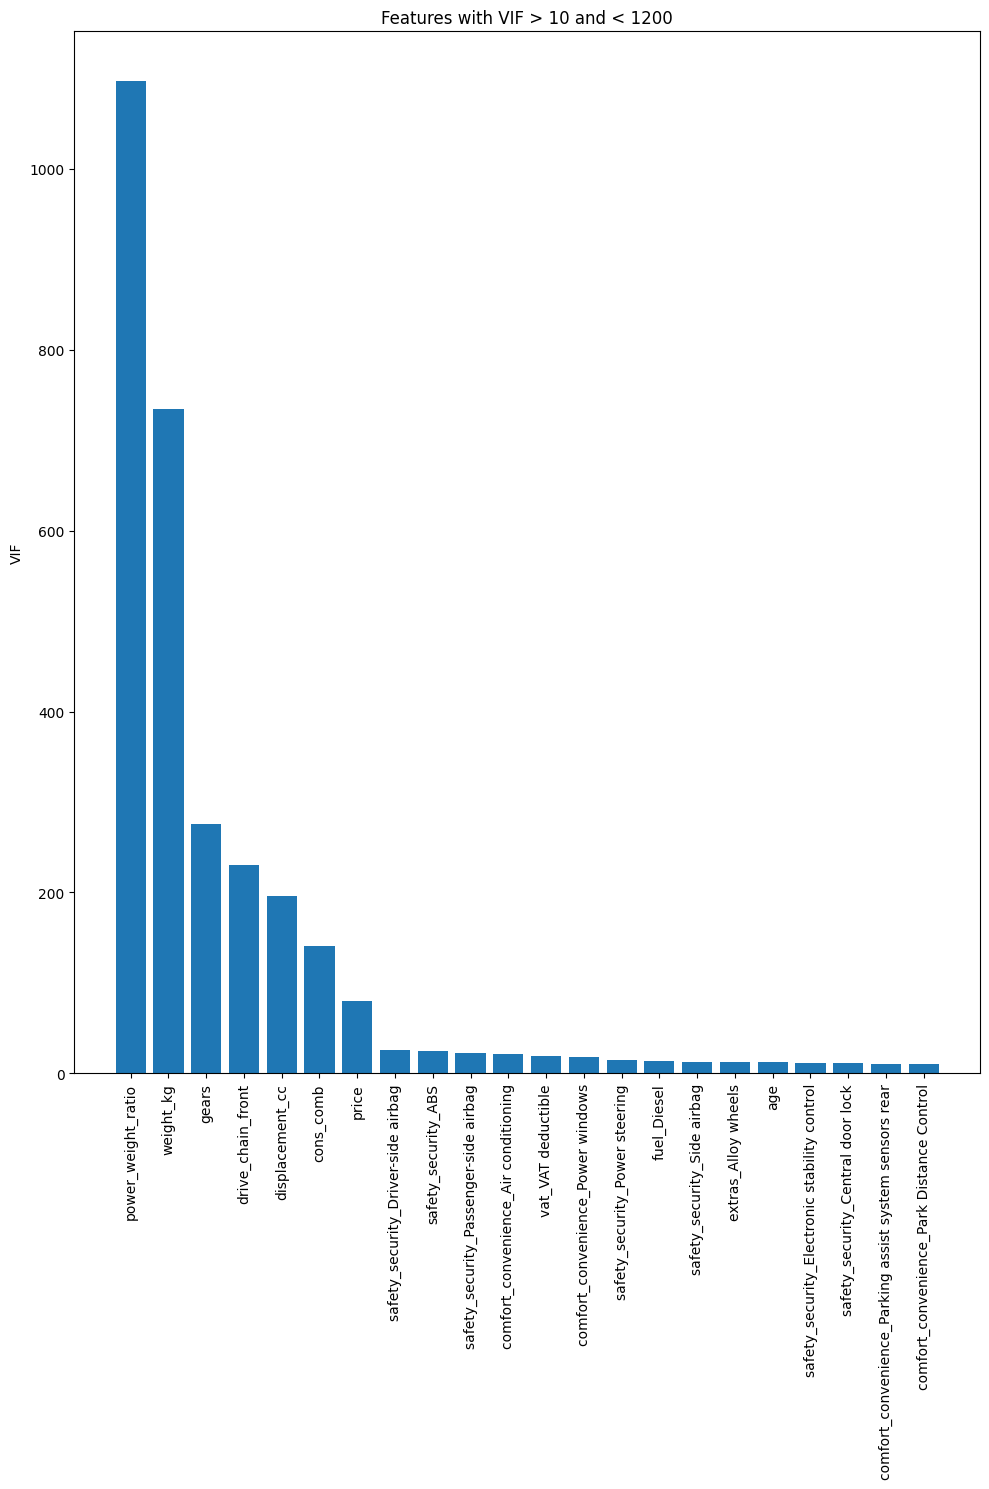

In [41]:
plot_vif(vif_df)

In [42]:
X_vif = X_train.copy()  # Use your cleaned numeric DataFrame

threshold = 10
while True:
    vif_df = calculate_vif(X_vif)
    max_vif = vif_df['VIF'].max()
    if max_vif > threshold:
        drop_feature = vif_df.sort_values('VIF', ascending=False)['Predictor'].iloc[0]
        print(f"Removing '{drop_feature}' with VIF={max_vif:.2f}")
        X_vif = X_vif.drop(columns=[drop_feature])
    else:
        break

print(vif_df)

Removing 'hp_kw' with VIF=1299.62
Removing 'weight_kg' with VIF=265.73
Removing 'gears' with VIF=187.20
Removing 'displacement_cc' with VIF=169.15
Removing 'drive_chain_front' with VIF=130.79
Removing 'cons_comb' with VIF=102.09
Removing 'power_weight_ratio' with VIF=64.55
Removing 'price' with VIF=31.60
Removing 'safety_security_Driver-side airbag' with VIF=25.21
Removing 'safety_security_ABS' with VIF=23.49
Removing 'comfort_convenience_Air conditioning' with VIF=19.39
Removing 'comfort_convenience_Power windows' with VIF=17.02
Removing 'safety_security_Passenger-side airbag' with VIF=16.15
Removing 'vat_VAT deductible' with VIF=14.72
Removing 'safety_security_Power steering' with VIF=13.06
Removing 'comfort_convenience_Parking assist system sensors rear' with VIF=10.67
Removing 'safety_security_Side airbag' with VIF=10.52
                                        Predictor       VIF
0                                              km  6.004606
1                                          

### **3.2 Ridge Regression Implementation** <font color =red> [10 marks] </font>

#### **3.2.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [111]:
# List of alphas to tune for Ridge regularisation

param_grid = {'alpha': np.linspace(0.0001, 1, 100)} 

#### **3.2.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [112]:
# Applying Ridge regression
ridge = Ridge()

# GridSearchCV for tuning Ridge hyperparameters
model_cv = GridSearchCV(estimator=ridge, param_grid = param_grid,
                        scoring = "neg_mean_absolute_error",
                        cv=5, n_jobs=-1, return_train_score=True, verbose=1)

model_cv.fit(X_train, y_train)

print(model_cv.best_estimator_.n_iter_)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
None


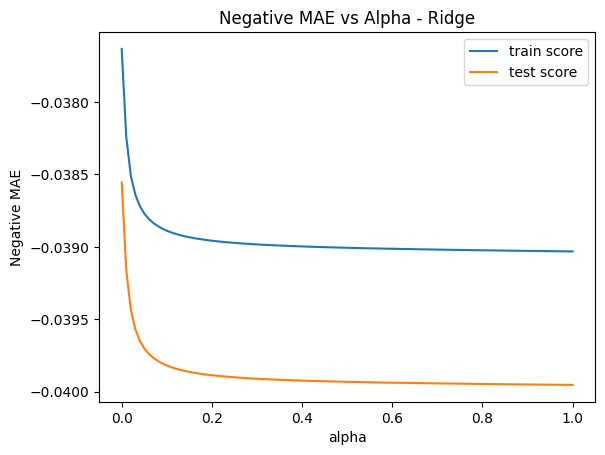

In [117]:
def plot_train_vs_test_alpha(model_cv): # Plot train and test scores against alpha
    cv_results = pd.DataFrame(model_cv.cv_results_)

    # Convert alpha to float for better plotting
    cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')

    # Plot train and test scores against alpha
    plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
    plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
    plt.xlabel('alpha')
    plt.ylabel('Negative MAE')

    plt.title("Negative MAE vs Alpha - Ridge")
    plt.legend(['train score', 'test score'], loc='upper right')
    plt.show()

plot_train_vs_test_alpha(model_cv)

Find the best alpha value.

In [114]:
# Best alpha value
best_ridge_alpha = model_cv.best_params_['alpha']
print(f"Best alpha: {best_ridge_alpha}")

# Best score (negative MAE)
best_score = model_cv.best_score_
print(f"Best negative MAE: {best_score}")



Best alpha: 0.0001
Best negative MAE: -0.03855509146887389


We will get some best value of alpha above. This however is not the most accurate value but the best value from the given list. Now we have a rough estimate of the range that best alpha falls in. Let us do another iteration over the values in a smaller range.

In [71]:
best_ridge_model = Ridge(alpha = best_ridge_alpha)
best_ridge_model = best_ridge_model.fit(X_train, y_train)
pd.DataFrame({"Feature": X_train.columns, "Coefficients - LR": lr.coef_, "Coefficients - Ridge": best_ridge_model.coef_}).round(2)

,Feature,Coefficients - LR,Coefficients - Ridge
0,price,0.00,0.00
1,km,-0.00,-0.00
2,gears,-0.00,-0.00
3,age,-0.02,-0.02
4,hp_kw,-0.01,-0.01
...,...,...,...
97,drive_chain_front,0.02,0.02
98,drive_chain_rear,0.03,0.03
99,age_category_Mid,0.00,0.00
100,age_category_Old,0.00,0.00


#### **3.2.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [72]:
# Take a smaller range of alpha to test
# Use a finer grid around the previously found best alpha
smaller_alphas = np.linspace(max(0.0001, best_ridge_alpha - 0.05), best_ridge_alpha + 0.05, 50)
param_grid_fine = {'alpha': smaller_alphas}



In [115]:
# Applying Ridge regression
ridge_fine = Ridge()
model_cv_fine = GridSearchCV(estimator=ridge_fine, param_grid=param_grid_fine,
                            scoring="neg_mean_absolute_error",
                            cv=5, n_jobs=-1, return_train_score=True, verbose=1)
model_cv_fine.fit(X_train, y_train)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': array([0.0001..., 0.0501 ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidat

Plot the error-alpha graph again and find the actual optimal value for alpha.

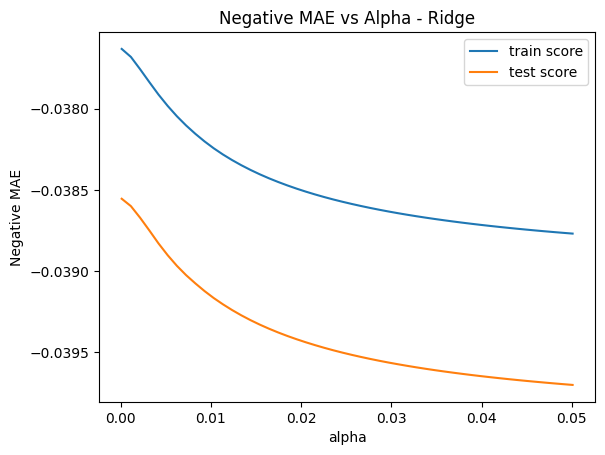

Best alpha (fine search): 0.0001
Best negative MAE (fine search): -0.03855509146887389


In [118]:
# Plot train and test scores against alpha
plot_train_vs_test_alpha(model_cv_fine)

# Best alpha value
tuned_best_alpha = model_cv_fine.best_params_['alpha']
print(f"Best alpha (fine search): {tuned_best_alpha}")


# Best score (negative MAE)
tuned_best_score = model_cv_fine.best_score_
print(f"Best negative MAE (fine search): {tuned_best_score}")


In [ ]:
# Set best alpha for Ridge regression
# Fit the Ridge model to get the coefficients of the fitted model
best_ridge_model_fine = Ridge(alpha=tuned_best_alpha)
best_ridge_model_fine.fit(X_train, y_train)

# Get coefficients of the fitted Ridge model
ridge_coefficients = best_ridge_model_fine.coef_

,Feature,Ridge Coefficient
0,price,0.00
1,km,-0.00
2,gears,-0.00
3,age,-0.02
4,hp_kw,-0.01
...,...,...
97,drive_chain_front,0.02
98,drive_chain_rear,0.03
99,age_category_Mid,0.00
100,age_category_Old,0.00


In [87]:
# Show the coefficients for each feature
pd.DataFrame({"Feature": X_train.columns, "Ridge Coefficient": ridge_coefficients}).round(2)


,Feature,Ridge Coefficient
0,price,0.00
1,km,-0.00
2,gears,-0.00
3,age,-0.02
4,hp_kw,-0.01
...,...,...
97,drive_chain_front,0.02
98,drive_chain_rear,0.03
99,age_category_Mid,0.00
100,age_category_Old,0.00


In [137]:
# Evaluate the Ridge model on the test data

# Predict on test set
ridge_test_pred = best_ridge_model_fine.predict(X_test)

# Calculate metrics
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))
ridge_test_mae = mean_absolute_error(y_test, ridge_test_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print(f"Ridge Test RMSE: {ridge_test_rmse:.3f}")
print(f"Ridge Test MAE: {ridge_test_mae:.3f}")
print(f"Ridge Test R^2: {ridge_test_r2:.3f}")

Ridge Test RMSE: 0.050
Ridge Test MAE: 0.038
Ridge Test R^2: 0.982


### **3.3 Lasso Regression Implementation** <font color =red> [10 marks] </font>

#### **3.3.1** <font color =red> [2 marks] </font>
Define a list of random alpha values

In [ ]:
# List of alphas to tune for Lasso regularisation

param_grid = {'alpha': np.linspace(0.001, 100, 7000)}  # 0.001 to 100, 7000 values


#### **3.3.2** <font color =red> [4 marks] </font>
Apply Ridge Regularisation and find the best value of alpha from the list

In [ ]:
# Initialise Lasso regression model
lasso = Lasso()

# GridSearchCV for tuning Lasso hyperparameters
model_cv_lasso_coarse = GridSearchCV(estimator=lasso, param_grid=param_grid,
                                     scoring="neg_mean_absolute_error",
                                     cv=5, n_jobs=-1, return_train_score=True, verbose=1)

# Fit the model
model_cv_lasso_coarse.fit(X_train, y_train)

# Check number of iterations for convergence
print(model_cv_lasso_coarse.best_estimator_.n_iter_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
94


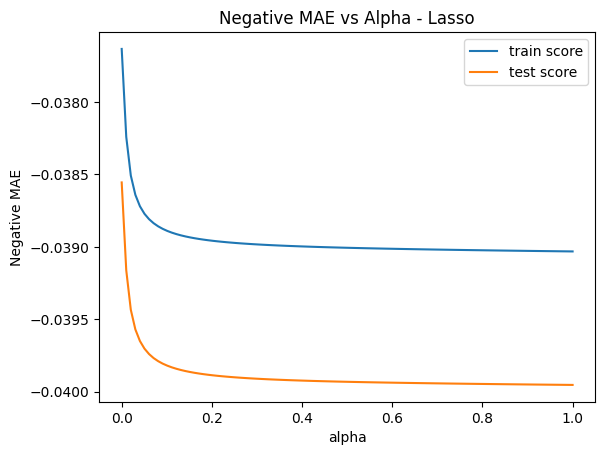

In [ ]:
# Plot train and test scores against alpha

# Convert cross-validation results to DataFrame
cv_results = pd.DataFrame(model_cv_lasso_coarse.cv_results_)

# Convert alpha to float for better plotting
cv_results['param_alpha'] = cv_results['param_alpha'].astype('float32')

# Plot train and test scores against alpha
plt.plot(cv_results['param_alpha'], cv_results['mean_train_score'])
plt.plot(cv_results['param_alpha'], cv_results['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative MAE')

plt.title("Negative MAE vs Alpha - Lasso")
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()

In [138]:
# Best alpha value
best_lasso_alpha_coarse = model_cv_lasso_coarse.best_params_['alpha']
print(f"Best alpha: {best_lasso_alpha_coarse}")

# Best score (negative MAE)
best_lasso_score_coarse = model_cv_lasso_coarse.best_score_
print(f"Best negative MAE: {best_lasso_score_coarse}")

Best alpha: 0.0001
Best negative MAE: -0.03995432237622539


#### **3.3.3** <font color =red> [4 marks] </font>
Fine tune by taking a closer range of alpha based on the previous result.

In [ ]:
# List of alphas to tune for Lasso regularization
lasso_alphas = np.linspace(max(0.0001, best_lasso_alpha_coarse - 0.05), best_lasso_alpha_coarse + 0.05, 100)
param_grid_lasso = {'alpha': lasso_alphas}


In [140]:
# Tuning Lasso hyperparameters
lasso = Lasso()
model_cv_lasso = GridSearchCV(estimator=lasso, param_grid=param_grid_lasso,
                              scoring="neg_mean_absolute_error",
                              cv=5, n_jobs=-1, return_train_score=True, verbose=1)
model_cv_lasso.fit(X_train, y_train)

print(f"Best Lasso alpha: {model_cv_lasso.best_params_['alpha']}")
print(f"Best negative MAE (Lasso): {model_cv_lasso.best_score_}")


Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Lasso alpha: 0.0001
Best negative MAE (Lasso): -0.03995432237622539


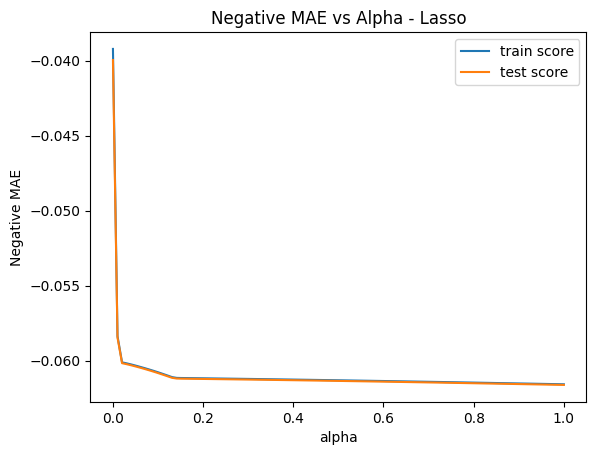

In [123]:
# Plot train and test scores against alpha
cv_results_lasso = pd.DataFrame(model_cv_lasso.cv_results_)
cv_results_lasso['param_alpha'] = cv_results_lasso['param_alpha'].astype('float32')

plt.plot(cv_results_lasso['param_alpha'], cv_results_lasso['mean_train_score'])
plt.plot(cv_results_lasso['param_alpha'], cv_results_lasso['mean_test_score'])
plt.xlabel('alpha')
plt.ylabel('Negative MAE')
plt.title('Negative MAE vs Alpha - Lasso')
plt.legend(['train score', 'test score'], loc='upper right')
plt.show()


In [141]:
# Best alpha value
best_lasso_alpha = model_cv_lasso.best_params_['alpha']
print(f"Best Lasso alpha: {best_lasso_alpha}")

# Best score (negative MAE)
tuned_lasso_score = model_cv_lasso.best_score_
print(f"Best negative MAE (Lasso): {tuned_lasso_score}")

Best Lasso alpha: 0.0001
Best negative MAE (Lasso): -0.03995432237622539


In [ ]:
# Set best alpha for Lasso regression
best_lasso_model = Lasso(alpha=best_lasso_alpha)

# Fit the Lasso model on scaled training data
best_lasso_model = best_lasso_model.fit(X_train, y_train)

# Get the coefficients of the fitted model
lasso_coefficients = best_lasso_model.coef_

,Feature,Lasso Coefficient
0,price,0.00
1,km,-0.00
2,gears,0.00
3,age,-0.02
4,hp_kw,0.00
...,...,...
97,drive_chain_front,0.01
98,drive_chain_rear,-0.00
99,age_category_Mid,0.00
100,age_category_Old,0.00


In [126]:
# Check the coefficients for each feature
pd.DataFrame({"Feature": X_train.columns, "Coefficients - Lasso": lasso_coefficients}).round(2)


,Feature,Coefficients - Lasso
0,price,0.00
1,km,-0.00
2,gears,0.00
3,age,-0.02
4,hp_kw,0.00
...,...,...
97,drive_chain_front,0.01
98,drive_chain_rear,-0.00
99,age_category_Mid,0.00
100,age_category_Old,0.00


In [143]:
# Evaluate the Lasso model on the test data
# Fit Lasso model with best alpha (MAE)
best_lasso_model_mae = Lasso(alpha=best_lasso_alpha)
best_lasso_model_mae.fit(X_train, y_train)

# Predict on test set
lasso_test_pred = best_lasso_model_mae.predict(X_test)

# Calculate metrics
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))
lasso_test_mae = mean_absolute_error(y_test, lasso_test_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

print(f"Lasso Test RMSE: {lasso_test_rmse:.3f}")
print(f"Lasso Test MAE: {lasso_test_mae:.3f}")
print(f"Lasso Test R^2: {lasso_test_r2:.3f}")

Lasso Test RMSE: 0.052
Lasso Test MAE: 0.040
Lasso Test R^2: 0.981


### **3.4 Regularisation Comparison & Analysis** <font color =red> [5 marks] </font>

#### **3.4.1** <font color =red> [2 marks] </font>
Compare the evaluation metrics for each model.

In [144]:
# Compare metrics for each model
metrics_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr.predict(X_test))),
        ridge_test_rmse,
        lasso_test_rmse
    ],
    "MAE": [
        mean_absolute_error(y_test, lr.predict(X_test)),
        ridge_test_mae,
        lasso_test_mae
    ],
    "R^2": [
        r2_score(y_test, lr.predict(X_test)),
        ridge_test_r2,
        lasso_test_r2
    ]
})

metrics_comparison.round(4)

,Model,RMSE,MAE,R^2
0,Linear Regression,0.0501,0.0380,0.9823
1,Ridge,0.0501,0.0380,0.9823
2,Lasso,0.0525,0.0399,0.9806


#### **3.4.2** <font color =red> [3 marks] </font>
Compare the coefficients for the three models.

Also visualise a few of the largest coefficients and the coefficients of features dropped by Lasso.

In [145]:
# Compare highest coefficients and coefficients of eliminated features
# Linear Regression coefficients
lr_coef = pd.Series(lr.coef_, index=X_train.columns)
# Ridge coefficients
ridge_coef = pd.Series(best_ridge_model_fine.coef_, index=X_train.columns)
# Lasso coefficients (MAE-tuned)
lasso_coef = pd.Series(best_lasso_model_mae.coef_, index=X_train.columns)

# Highest coefficients
print("Top 5 Linear Regression coefficients:")
print(lr_coef.abs().sort_values(ascending=False).head())
print("Top 5 Ridge coefficients:")
print(ridge_coef.abs().sort_values(ascending=False).head())
print("Top 5 Lasso coefficients:")
print(lasso_coef.abs().sort_values(ascending=False).head())

# Features eliminated by Lasso (coefficients = 0)
eliminated_features = lasso_coef[lasso_coef == 0].index.tolist()
print("Features eliminated by Lasso: " + str(len(eliminated_features)))
print(eliminated_features)


Top 5 Linear Regression coefficients:
power_weight_ratio           11.758838
make_model_Opel Corsa         0.204346
make_model_Renault Clio       0.169152
make_model_Renault Espace     0.107370
make_model_Audi A2            0.066087
dtype: float64
Top 5 Ridge coefficients:
power_weight_ratio           11.629635
make_model_Opel Corsa         0.204402
make_model_Renault Clio       0.169182
make_model_Renault Espace     0.106772
make_model_Audi A2            0.066353
dtype: float64
Top 5 Lasso coefficients:
make_model_Opel Corsa      0.196972
make_model_Renault Clio    0.162966
make_model_Opel Astra      0.058974
gearing_type_Manual        0.046381
body_type_Other            0.041583
dtype: float64
Features eliminated by Lasso: 24
['power_weight_ratio', 'comfort_convenience_Automatic climate control', 'comfort_convenience_Hill Holder', 'comfort_convenience_Light sensor', 'comfort_convenience_Lumbar support', 'comfort_convenience_Parking assist system sensors front', 'comfort_convenience_T

## **4 Conclusion & Key Takeaways**  <font color =red> [10 marks] </font>

What did you notice by performing regularisation? Did the model performance improve? If not, then why? Did you find overfitting or not? Was the data sufficent? Is a linear model sufficient?

#### **4.1 Conclude with outcomes and insights gained** <font color =red> [10 marks] </font>

- Performing regularisation did not materially improve predictive performance in this notebook. The baseline Linear Regression and Ridge Regression produced almost identical test results, with RMSE around 0.0501, MAE around 0.0380, and $R^2$ around 0.9823.

- Ridge selected an alpha value very close to zero (`0.0001`), which indicates that only a negligible amount of shrinkage was needed. This suggests the original linear model was already well-regularised by the data and preprocessing steps.

- Lasso produced a slightly worse test performance, with RMSE around 0.0525, MAE around 0.0399, and $R^2$ around 0.9806. However, it eliminated 24 out of 102 coefficients, so it gave a sparser and more interpretable model at the cost of a small drop in accuracy.

- There is no strong evidence of overfitting. The baseline model already showed nearly identical training and testing performance, which means the model generalised well even before applying Ridge or Lasso.

- The data appears sufficient for a linear model. The very high test $R^2$ and low error values indicate that the available predictors explain most of the variation in the target.

- A linear model is sufficient for this problem based on the current results. Regularisation was still useful as a diagnostic tool and for feature selection, but it was not necessary for improving accuracy in this case.